In [1]:
from pymongo import MongoClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from glob import glob

client = MongoClient('mongodb://localhost:27017/')
db = client['quasar_db']
objects = db.objects
spectra = db.spectra
curves = db.light_curves

#function to get the source link in the DB of a short reference e.g. Shen2024
REFERENCE_TO_LINK = {
    "Shen2024": "https://iopscience.iop.org/article/10.3847/1538-4365/ad3936/pdf",
    "Kaspi2000": "https://iopscience.iop.org/article/10.1086/308704/pdf",
    "Bentz2013": "https://iopscience.iop.org/article/10.1088/0004-637X/767/2/149/pdf",
    "Peterson1998": "https://iopscience.iop.org/article/10.1086/305813",
    "Grier2012": "https://iopscience.iop.org/article/10.1088/0004-637X/755/1/60",
    "Santos-Lleo1997": "https://iopscience.iop.org/article/10.1086/313046",
    "Denney2009": "https://iopscience.iop.org/article/10.1088/0004-637X/702/2/1353",
    "Bentz2009b": "https://iopscience.iop.org/article/10.1088/0004-637X/705/1/199",
    "Stirpe1994": "https://ui.adsabs.harvard.edu/abs/1994ApJ...425..609S/abstract",
    "Bentz2006a": "https://iopscience.iop.org/article/10.1086/507417",
    "Denney2006": "https://iopscience.iop.org/article/10.1086/508533",
    "Winge1996": "https://ui.adsabs.harvard.edu/abs/1996ApJ...469..648W/abstract",
    "SantosLleo2001": "https://www.aanda.org/articles/aa/abs/2001/13/aa9537/aa9537.html",
    "Peterson2002": "https://iopscience.iop.org/article/10.1086/344197",
    "Bentz2007": "https://iopscience.iop.org/article/10.1086/516724",
    "Dietrich1998": "https://iopscience.iop.org/article/10.1086/313085",
    "Dietrich2012": "https://iopscience.iop.org/article/10.1088/0004-637X/757/1/53",
    "Peterson2014": "https://ui.adsabs.harvard.edu/abs/2014ApJ...795..149P/abstract",
    "Kaspi2021": "https://iopscience.iop.org/article/10.3847/1538-4357/ac00aa/pdf",
    "Lira2018": "https://iopscience.iop.org/article/10.3847/1538-4357/aada45/pdf",
    "McDougall2025": "https://arxiv.org/pdf/2512.01261",
    "Hoormann2019": "https://ui.adsabs.harvard.edu/abs/2019MNRAS.487.3650H/abstract",
    "Peterson2005": "https://iopscience.iop.org/article/10.1086/444494/pdf",
    "Metzroth2006": "https://iopscience.iop.org/article/10.1086/505525/pdf",
    "De Rosa2015": "https://iopscience.iop.org/article/10.1088/0004-637X/806/1/128/pdf",
    "Penton2025": "https://arxiv.org/pdf/2512.01260",
    "Hu2025": "https://iopscience.iop.org/article/10.3847/1538-4365/add40b/pdf",
    "Woo2024": "https://iopscience.iop.org/article/10.3847/1538-4357/ad132f/pdf",
    'Hu2021': 'https://iopscience.iop.org/article/10.3847/1538-4365/abd774/pdf',
    'Bai2025': 'https://arxiv.org/pdf/2512.08192',
    'Grier2017': 'https://iopscience.iop.org/article/10.3847/1538-4357/aa98dc/pdf'
}
LINK_TO_REFERENCE = {v: k for k, v in REFERENCE_TO_LINK.items()}

def reference_finder(link: str):
    return LINK_TO_REFERENCE.get(link)

def link_finder(reference: str):
    return REFERENCE_TO_LINK.get(reference)

def get_lag_from_source(object, line, short_source):
    correct_index = None
    entry = object.get('properties', {}).get('lags', {}).get(f'{line}', {})
    if short_source == 'Bentz2013' and len(entry) > 0:
        indexes = []
        for i in range(len(entry)):
            if entry[i]['source'] == link_finder(short_source):
                indexes.append(i)
                correct_index = i
        if correct_index == None:
            print(f'{short_source} has no reported {line} lag for the cursors object!')
        else:
            lag = []
            lag_error_plus = []
            lag_error_minus = []
            lag_grade = []
            for i in range(len(indexes)):
                lag.append(entry[indexes[i]]['value'])
                lag_error_plus.append(entry[indexes[i]]['error +'])
                lag_error_minus.append(entry[indexes[i]]['error -'])
                lag_grade_entry = entry[indexes[i]]['grade']
                if lag_grade_entry == 'unknown':
                    lag_grade.append(-1)
                elif lag_grade_entry in ['bronze', 'silver', 'gold']:
                    lag_grade.append(-1)
                else:
                    lag_grade.append(lag_grade_entry)
    else:
        for i in range(len(entry)):
            if entry[i]['source'] == link_finder(short_source):
                correct_index = i
        if correct_index == None:
            print(f'{short_source} has no reported {line} lag for the cursors object!')
        else:
            lag = entry[correct_index]['value']
            lag_error_plus = entry[correct_index]['error +']
            lag_error_minus = entry[correct_index]['error -']
            lag_grade = entry[correct_index]['grade']
            if lag_grade == 'unknown':
                lag_grade = -1
            if lag_grade in ['bronze', 'silver', 'gold']:
                lag_grade = -1
    return lag, lag_error_plus, lag_error_minus, lag_grade
def get_all_lags(object, line, include_problematic):
    lag_entries = object.get('properties', {}).get('lags', {}).get(f'{line}')
    lag = []
    lag_error_plus = []
    lag_error_minus = []
    combined_from = []
    if include_problematic is True:
        for i in range(len(lag_entries)):
            lag.append(lag_entries[i]['value'])
            lag_error_plus.append(lag_entries[i]['error +'])
            lag_error_minus.append(lag_entries[i]['error -'])
            link = lag_entries[i]['source']
            combined_from.append(reference_finder(link))
    if include_problematic is False:
        for i in range(len(lag_entries)):
            problematic = lag_entries[i]['problematic']
            if problematic is True:
                continue
            if problematic is False:
                lag.append(lag_entries[i]['value'])
                lag_error_plus.append(lag_entries[i]['error +'])
                lag_error_minus.append(lag_entries[i]['error -'])
                link = lag_entries[i]['source']
                combined_from.append(reference_finder(link))
    if len(lag) == 0:
        return None
    else:
        return lag, lag_error_plus, lag_error_minus, combined_from
def combine_quantity(quantity, error_plus, error_minus, method):
    if method == 'weighted_mean':
        quantity = np.array(quantity)
        weights = np.zeros_like(error_plus)
        for i in range(len(error_plus)):
            err = 0.5 * (error_plus[i] + error_minus[i])
            weights[i] = 1/(err**2)
        mean = np.sum(quantity * weights) / np.sum(weights)
        error = np.sqrt(1 / np.sum(weights))
        return mean, error
    if method == 'envelope':
        lowest = min(np.array(quantity) - np.array(error_minus))
        highest = max(np.array(quantity) + np.array(error_plus))
        value = 0.5 * (lowest+highest)
        error = 0.5 * (highest-lowest)
        return value, error

def get_lag(object, line,*, 
            mode: str = 'simple', 
            source: str | None = None,
            used_id: list | None = None,
            include_problematic: bool = True,
            combine_method: str = "envelope"):
    if mode == 'simple':
        if source is None:
            raise ValueError("mode = 'simple' requires source")
        lag, lag_error_plus, lag_error_minus, lag_grade = get_lag_from_source(object, line, source)
        return lag, lag_error_plus, lag_error_minus, lag_grade
    if mode == 'simple filtered':
        if source is None:
            raise ValueError("mode = 'simple filtered' requires source")
        if used_id is None:
            raise ValueError("mode = 'simple filtered' requires used_id")
        object_id_to_be_received = object.get('_id')
        if object_id_to_be_received in used_id:
            name = object.get('names')[0]
            print('lag from ' + source + ' for ' + name + " won't be included since another source is used")
            return None
        else:
            used_id.append(object_id_to_be_received)
            lag, lag_error_plus, lag_error_minus, lag_grade = get_lag_from_source(object, line, source)
            return lag, lag_error_plus, lag_error_minus, lag_grade
    if mode == 'combine lags':
        result_get_all_lags = get_all_lags(object, line, include_problematic)
        if result_get_all_lags is not None:
            lags, lags_error_plus, lags_error_minus, combined_from = result_get_all_lags
            lag, lag_error = combine_quantity(lags, lags_error_plus, lags_error_minus, combine_method)
            return lag, lag_error, combined_from
        if result_get_all_lags is None:
            return None

def get_luminosity_from_source(object, L, short_source):
    correct_index = None
    entry = object.get('properties', {}).get(f'{L}', {}).get(f'{short_source}', {})
    if short_source == 'Bentz2013' and len(entry) > 0:
        indexes = []
        for i in range(len(entry)):
            if entry[i]['source'] == link_finder(short_source):
                indexes.append(i)
                correct_index = i
        if correct_index == None:
            print(f'{short_source} has no reported {L} measurment for the cursors object!')
        else:
            value = []
            error = []
            for i in range(len(indexes)):
                value.append(entry[indexes[i]]['value'])
                if 'error' in entry[indexes[i]].keys():
                    error.append(entry[indexes[i]]['error'])
                else:
                    error.append(0)
    else:
        for i in range(len(entry)):
            if entry[i]['source'] == link_finder(short_source):
                correct_index = i
        if correct_index == None:
            print(f'{short_source} has no reported {L} measurment for the cursors object!')
        else:
            value = entry[correct_index]['value']
            if 'error' in entry[correct_index].keys():
                error = entry[correct_index]['error']
            else:
                error = 0
    return value, error
def get_all_luminosities(object, L, include_problematic):
    lum_keys = object.get('properties', {}).get(f'{L}', {})
    lum = []
    lum_error = []
    combined_from = []
    for data_set in lum_keys.keys():
        entry = lum_keys.get(f'{data_set}', {})[0]
        if include_problematic is True:
            lum.append(entry['value'])
            if 'error' in entry.keys():
                error = entry['error']
            else:
                error = entry['value'] * 0.1
            lum_error.append(error)
            combined_from.append(reference_finder(entry['source']))
        if include_problematic is False:
            if entry['problematic'] is True:
                continue
            if entry['problematic'] is False:
                lum.append(entry['value'])
                if 'error' in entry.keys():
                    error = entry['error']
                else:
                    error = entry['value'] * 0.1
                lum_error.append(error)
                combined_from.append(reference_finder(entry['source']))
    if len(lum) == 0:
        return None
    else:
        return lum, lum_error, combined_from

def get_luminosity(object, L,*, 
            mode: str = 'simple', 
            source: str | None = None,
            used_id: list | None = None,
            include_problematic: bool = True,
            combine_method: str = "envelope"):
    if mode == 'simple':
        if source is None:
            raise ValueError("mode = 'simple' requires source")
        value, error = get_luminosity_from_source(object, L, source)
        return value, error
    if mode == 'simple filtered':
        if source is None:
            raise ValueError("mode = 'simple filtered' requires source")
        if used_id is None:
            raise ValueError("mode = 'simple filtered' requires used_id")
        object_id_to_be_received = object.get('_id')
        if object_id_to_be_received in used_id:
            name = object.get('names')[0]
            print('Luminosity from ' + source + ' for ' + name + " won't be included since another source is used")
            return None
        else:
            used_id.append(object_id_to_be_received)
            value, error = get_luminosity_from_source(object, L, source)
            return value, error
    if mode == 'combine luminosities':
        result = get_all_luminosities(object, L, include_problematic)
        if result == None:
            return None
        else:
            values, errors, combined_from = result
            value, error = combine_quantity(values, errors, errors, combine_method)
            return value, error, combined_from
        
def shaded_fit(a, a_plus, a_minus, b, b_plus, b_minus, x):
    a_werte = np.linspace(a-a_minus, a+a_plus, 40)
    b_werte = np.linspace(b-b_minus, b+b_plus, 40)
    Y = []
    for a_1 in a_werte:
        for b_1 in b_werte:
            Y.append(fit(x, a_1, b_1))
    Y = np.array(Y)
    y_min = Y.min(axis = 0)
    y_max = Y.max(axis =0)
    return y_min, y_max

def rl_model_with_errors(L, alpha, alpha_err_minus, alpha_err_plus,
    beta, beta_err_minus, beta_err_plus, sigma):
    logL = np.log10(L)
    logR = beta + alpha * logL

    logR_err_plus = np.sqrt((logL * alpha_err_plus)**2 + (beta_err_plus)**2)
    logR_err_minus = np.sqrt((logL * alpha_err_minus)**2 + (beta_err_minus)**2)

    y_med = 10**logR
    y_low = 10**(logR - logR_err_minus)
    y_high = 10**(logR + logR_err_plus)

    y_scatter_low = 10**(logR - sigma)
    y_scatter_high = 10**(logR + sigma)

    return y_med, y_low, y_high, y_scatter_low, y_scatter_high

### Literature R-L relations

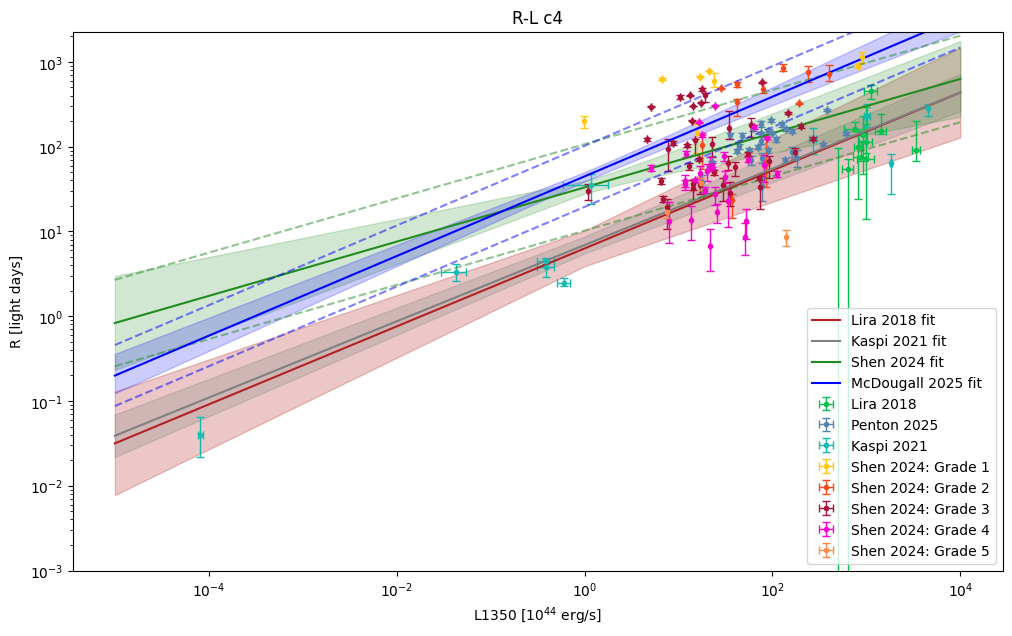

In [2]:
cursor = objects.find({'$and':[{'properties.lags.c4': {'$exists': True}}, {'properties.L1350.Lira2018': {'$exists': True}}]})

lag_Lira2018 = []
lag_error_plus_Lira2018 = []
lag_error_minus_Lira2018 = []
lag_grade_Lira2018 = []

L_Lira2018 = []
L_error_Lira2018 = []

for object in cursor:
    lag, lag_error_plus, lag_error_minus, lag_grade = get_lag(object, 'c4', mode = 'simple',source = 'Lira2018')
    L, L_error = get_luminosity(object, 'L1350', mode = 'simple',source ='Lira2018')
    lag_Lira2018.append(lag)
    lag_error_plus_Lira2018.append(lag_error_plus)
    lag_error_minus_Lira2018.append(lag_error_minus)
    lag_grade_Lira2018.append(lag_grade)
    L_Lira2018.append(L / 1e44)
    L_error_Lira2018.append(L_error / 1e44)

cursor = objects.find({'$and':[{'properties.lags.c4': {'$exists': True}}, {'properties.L1350.Penton2025': {'$exists': True}}]})

lag_Penton2025 = []
lag_error_plus_Penton2025 = []
lag_error_minus_Penton2025 = []
lag_grade_Penton2025 = []

L_Penton2025 = []
L_error_Penton2025 = []

for object in cursor:
    lag, lag_error_plus, lag_error_minus, lag_grade = get_lag(object, 'c4',mode = 'simple', source = 'Penton2025')
    L, L_error = get_luminosity(object, 'L1350', mode = 'simple',source ='Penton2025')
    lag_Penton2025.append(lag)
    lag_error_plus_Penton2025.append(lag_error_plus)
    lag_error_minus_Penton2025.append(lag_error_minus)
    lag_grade_Penton2025.append(lag_grade)
    L_Penton2025.append(L / 1e44)
    L_error_Penton2025.append(L_error / 1e44)

cursor = objects.find({'$and':[{'properties.lags.c4': {'$exists': True}}, {'properties.L1350.Kaspi2021': {'$exists': True}}]})

lag_Kaspi2021 = []
lag_error_plus_Kaspi2021 = []
lag_error_minus_Kaspi2021 = []
lag_grade_Kaspi2021 = []

L_Kaspi2021 = []
L_error_Kaspi2021 = []

for object in cursor:
    lag, lag_error_plus, lag_error_minus, lag_grade = get_lag(object, 'c4',mode = 'simple', source = 'Kaspi2021')
    L, L_error = get_luminosity(object, 'L1350', mode = 'simple',source ='Kaspi2021')
    lag_Kaspi2021.append(lag)
    lag_error_plus_Kaspi2021.append(lag_error_plus)
    lag_error_minus_Kaspi2021.append(lag_error_minus)
    lag_grade_Kaspi2021.append(lag_grade)
    L_Kaspi2021.append(L / 1e44)
    L_error_Kaspi2021.append(L_error / 1e44)

cursor = objects.find({'$and':[{'properties.lags.c4': {'$exists': True}}, {'properties.L1350.Shen2024': {'$exists': True}}]})

lag_Shen2024 = []
lag_error_plus_Shen2024 = []
lag_error_minus_Shen2024 = []
lag_grade_Shen2024 = []

L_Shen2024 = []
L_error_Shen2024 = []

for object in cursor:
    lag, lag_error_plus, lag_error_minus, lag_grade = get_lag(object, 'c4',mode = 'simple', source = 'Shen2024')
    L, L_error = get_luminosity(object, 'L1350', mode = 'simple',source ='Shen2024')
    lag_Shen2024.append(lag)
    lag_error_plus_Shen2024.append(lag_error_plus)
    lag_error_minus_Shen2024.append(lag_error_minus)
    lag_grade_Shen2024.append(lag_grade)
    L_Shen2024.append(L / 1e44)
    L_error_Shen2024.append(L_error / 1e44)

index_1 = [i for i, e in enumerate(lag_grade_Shen2024) if e ==1]
index_2 = [i for i, e in enumerate(lag_grade_Shen2024) if e ==2]
index_3 = [i for i, e in enumerate(lag_grade_Shen2024) if e ==3]
index_4 = [i for i, e in enumerate(lag_grade_Shen2024) if e ==4]
index_5 = [i for i, e in enumerate(lag_grade_Shen2024) if e ==5]
L_1_Shen2024 = np.array([L_Shen2024[i] for i in index_1])
L_2_Shen2024 = np.array([L_Shen2024[i] for i in index_2])
L_3_Shen2024 = np.array([L_Shen2024[i] for i in index_3])
L_4_Shen2024 = np.array([L_Shen2024[i] for i in index_4])
L_5_Shen2024 = np.array([L_Shen2024[i] for i in index_5])
L_1_error_Shen2024 = np.array([L_error_Shen2024[i] for i in index_1])
L_2_error_Shen2024 = np.array([L_error_Shen2024[i] for i in index_2])
L_3_error_Shen2024 = np.array([L_error_Shen2024[i] for i in index_3])
L_4_error_Shen2024 = np.array([L_error_Shen2024[i] for i in index_4])
L_5_error_Shen2024 = np.array([L_error_Shen2024[i] for i in index_5])
lag_1_Shen2024 = np.array([lag_Shen2024[i] for i in index_1])
lag_2_Shen2024 = np.array([lag_Shen2024[i] for i in index_2])
lag_3_Shen2024 = np.array([lag_Shen2024[i] for i in index_3])
lag_4_Shen2024 = np.array([lag_Shen2024[i] for i in index_4])
lag_5_Shen2024 = np.array([lag_Shen2024[i] for i in index_5])
lag_error_plus_1_Shen2024 = np.array([lag_error_plus_Shen2024[i] for i in index_1])
lag_error_plus_2_Shen2024 = np.array([lag_error_plus_Shen2024[i] for i in index_2])
lag_error_plus_3_Shen2024 = np.array([lag_error_plus_Shen2024[i] for i in index_3])
lag_error_plus_4_Shen2024 = np.array([lag_error_plus_Shen2024[i] for i in index_4])
lag_error_plus_5_Shen2024 = np.array([lag_error_plus_Shen2024[i] for i in index_5])
lag_error_minus_1_Shen2024 = np.array([lag_error_minus_Shen2024[i] for i in index_1])
lag_error_minus_2_Shen2024 = np.array([lag_error_minus_Shen2024[i] for i in index_2])
lag_error_minus_3_Shen2024 = np.array([lag_error_minus_Shen2024[i] for i in index_3])
lag_error_minus_4_Shen2024 = np.array([lag_error_minus_Shen2024[i] for i in index_4])
lag_error_minus_5_Shen2024 = np.array([lag_error_minus_Shen2024[i] for i in index_5])

x = np.linspace(1e39, 1e48, 10000) / 1e44
def fit(x, a, b):
    return 10**a*x**b

#Shen24 fitparameter
y_min_Shen24, y_max_Shen24 = shaded_fit(1.84, 0.075, 0.073, 0.32, 0.11, 0.11, x)
#Lira18 fitparameter
y_min_Lira18, y_max_Lira18 = shaded_fit(0.80,0.21,0.21,0.46,0.08,0.08,x)
#Kaspi21 fitparameter
y_min_Kaspi21, y_max_Kaspi21 = shaded_fit(0.84,0.1,0.1,0.45,0.03,0.03,x)
#McDougall fitparameter
y_min_McDougall25, y_max_McDougall25 = shaded_fit(1.18,0.05,0.06,0.47,0.05,0.04,x)
def model(x, A, b, c, x0):
    return A * x ** b * (1 + x/x0)**-c
y_med_Shen24, y_low_Shen24, y_high_Shen24, y_s_lo_Shen24, y_s_hi_Shen24 = rl_model_with_errors(
    x, 0.32, 0.11, 0.11, 1.52, 0.073, 0.075 ,0.51)
y_med_McDougall, y_low_McDougall, y_high_McDougall, y_s_lo_McDougall, y_s_hi_McDougall = rl_model_with_errors(
    x, 0.47, 0.04, 0.05, 1.65, 0.06, 0.05, 0.36)

plt.figure(figsize = (12,7))
plt.xscale('log')
plt.yscale('log')
plt.errorbar(L_Lira2018, lag_Lira2018 ,xerr = L_error_Lira2018, yerr = [lag_error_minus_Lira2018, lag_error_plus_Lira2018] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Lira 2018', color = 'xkcd:Shamrock green')
plt.errorbar(L_Penton2025, lag_Penton2025 ,xerr = L_error_Penton2025,yerr = [lag_error_minus_Penton2025, lag_error_plus_Penton2025] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Penton 2025', color = 'xkcd:Off blue')
plt.errorbar(L_Kaspi2021, lag_Kaspi2021 ,xerr = L_error_Kaspi2021,yerr = [lag_error_minus_Kaspi2021, lag_error_plus_Kaspi2021] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Kaspi 2021', color = 'xkcd:Topaz')
plt.errorbar(L_1_Shen2024, lag_1_Shen2024 ,xerr = L_1_error_Shen2024,yerr = [lag_error_minus_1_Shen2024, lag_error_plus_1_Shen2024] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Shen 2024: Grade 1', color = 'xkcd:Sunflower')
plt.errorbar(L_2_Shen2024, lag_2_Shen2024 ,xerr = L_2_error_Shen2024,yerr = [lag_error_minus_2_Shen2024, lag_error_plus_2_Shen2024] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Shen 2024: Grade 2', color = 'xkcd:Reddish Orange')
plt.errorbar(L_3_Shen2024, lag_3_Shen2024 ,xerr = L_3_error_Shen2024,yerr = [lag_error_minus_3_Shen2024, lag_error_plus_3_Shen2024] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Shen 2024: Grade 3', color = 'xkcd:Rouge')
plt.errorbar(L_4_Shen2024, lag_4_Shen2024 ,xerr = L_4_error_Shen2024,yerr = [lag_error_minus_4_Shen2024, lag_error_plus_4_Shen2024] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Shen 2024: Grade 4', color = 'xkcd:Hot magenta')
plt.errorbar(L_5_Shen2024, lag_5_Shen2024 ,xerr = L_5_error_Shen2024,yerr = [lag_error_minus_5_Shen2024, lag_error_plus_5_Shen2024] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Shen 2024: Grade 5', color = 'xkcd:Orangeish')
plt.xlabel(r'L1350 [$10^{44}$ erg/s]')
plt.ylabel('R [light days]')
plt.title('R-L c4')
plt.ylim(bottom = 1e-3)
plt.fill_between(x, y_min_Lira18, y_max_Lira18, alpha = 0.25, color = 'firebrick')
plt.plot(x, fit(x, 0.80, 0.46), label = 'Lira 2018 fit', color = 'firebrick')
plt.fill_between(x, y_min_Kaspi21, y_max_Kaspi21, alpha = 0.25, color = 'gray')
plt.plot(x, fit(x, 0.84, 0.45), label = 'Kaspi 2021 fit', color = 'gray')
plt.fill_between(x, y_low_Shen24, y_high_Shen24, color='forestgreen', alpha=0.2)
plt.plot(x, y_med_Shen24, color='forestgreen', label = 'Shen 2024 fit')
plt.plot(x, y_s_lo_Shen24, color = 'forestgreen', ls = '--', alpha = 0.5)
plt.plot(x, y_s_hi_Shen24, color = 'forestgreen', ls = '--', alpha = 0.5)
plt.fill_between(x, y_low_McDougall, y_high_McDougall, color='blue', alpha=0.2)
plt.plot(x, y_med_McDougall, color='blue', label = 'McDougall 2025 fit')
plt.plot(x, y_s_lo_McDougall, color = 'blue', ls = '--', alpha = 0.5)
plt.plot(x, y_s_hi_McDougall, color = 'blue', ls = '--', alpha = 0.5)
plt.legend(loc = 'best')
plt.show()

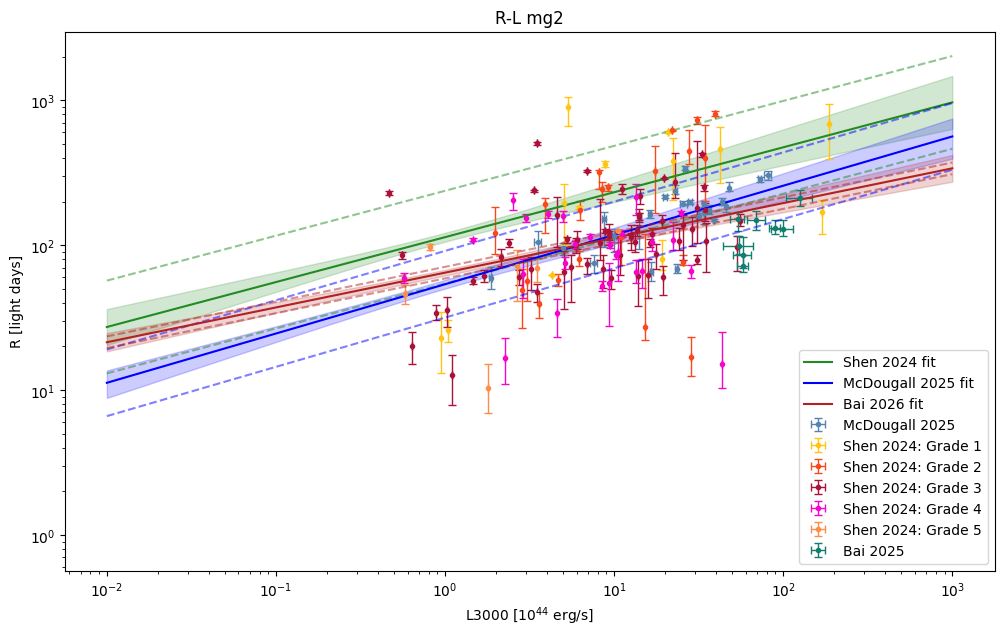

In [3]:
cursor = objects.find({'$and':[{'properties.lags.mg2': {'$exists': True}}, {'properties.L3000.McDougall2025': {'$exists': True}}]})

lag_McDougall2025 = []
lag_error_plus_McDougall2025 = []
lag_error_minus_McDougall2025 = []
lag_grade_McDougall2025 = []

L_McDougall2025 = []
L_error_McDougall2025 = []

for object in cursor:
    lag, lag_error_plus, lag_error_minus, lag_grade = get_lag(object, 'mg2', mode = 'simple', source ='McDougall2025')
    L, L_error = get_luminosity(object, 'L3000',mode = 'simple', source = 'McDougall2025')
    lag_McDougall2025.append(lag)
    lag_error_plus_McDougall2025.append(lag_error_plus)
    lag_error_minus_McDougall2025.append(lag_error_minus)
    lag_grade_McDougall2025.append(lag_grade)
    L_McDougall2025.append(L / 1e44)
    L_error_McDougall2025.append(L_error / 1e44)

cursor = objects.find({'$and':[{'properties.lags.mg2': {'$exists': True}}, {'properties.L3000.Shen2024': {'$exists': True}}]})

lag_Shen2024 = []
lag_error_plus_Shen2024 = []
lag_error_minus_Shen2024 = []
lag_grade_Shen2024 = []

L_Shen2024 = []
L_error_Shen2024 = []

for object in cursor:
    lag, lag_error_plus, lag_error_minus, lag_grade = get_lag(object, 'mg2',mode = 'simple', source = 'Shen2024')
    L, L_error = get_luminosity(object, 'L3000',mode = 'simple', source = 'Shen2024')
    lag_Shen2024.append(lag)
    lag_error_plus_Shen2024.append(lag_error_plus)
    lag_error_minus_Shen2024.append(lag_error_minus)
    lag_grade_Shen2024.append(lag_grade)
    L_Shen2024.append(L / 1e44)
    L_error_Shen2024.append(L_error / 1e44)

index_1 = [i for i, e in enumerate(lag_grade_Shen2024) if e ==1]
index_2 = [i for i, e in enumerate(lag_grade_Shen2024) if e ==2]
index_3 = [i for i, e in enumerate(lag_grade_Shen2024) if e ==3]
index_4 = [i for i, e in enumerate(lag_grade_Shen2024) if e ==4]
index_5 = [i for i, e in enumerate(lag_grade_Shen2024) if e ==5]
L_1_Shen2024 = np.array([L_Shen2024[i] for i in index_1])
L_2_Shen2024 = np.array([L_Shen2024[i] for i in index_2])
L_3_Shen2024 = np.array([L_Shen2024[i] for i in index_3])
L_4_Shen2024 = np.array([L_Shen2024[i] for i in index_4])
L_5_Shen2024 = np.array([L_Shen2024[i] for i in index_5])
L_1_error_Shen2024 = np.array([L_error_Shen2024[i] for i in index_1])
L_2_error_Shen2024 = np.array([L_error_Shen2024[i] for i in index_2])
L_3_error_Shen2024 = np.array([L_error_Shen2024[i] for i in index_3])
L_4_error_Shen2024 = np.array([L_error_Shen2024[i] for i in index_4])
L_5_error_Shen2024 = np.array([L_error_Shen2024[i] for i in index_5])
lag_1_Shen2024 = np.array([lag_Shen2024[i] for i in index_1])
lag_2_Shen2024 = np.array([lag_Shen2024[i] for i in index_2])
lag_3_Shen2024 = np.array([lag_Shen2024[i] for i in index_3])
lag_4_Shen2024 = np.array([lag_Shen2024[i] for i in index_4])
lag_5_Shen2024 = np.array([lag_Shen2024[i] for i in index_5])
lag_error_plus_1_Shen2024 = np.array([lag_error_plus_Shen2024[i] for i in index_1])
lag_error_plus_2_Shen2024 = np.array([lag_error_plus_Shen2024[i] for i in index_2])
lag_error_plus_3_Shen2024 = np.array([lag_error_plus_Shen2024[i] for i in index_3])
lag_error_plus_4_Shen2024 = np.array([lag_error_plus_Shen2024[i] for i in index_4])
lag_error_plus_5_Shen2024 = np.array([lag_error_plus_Shen2024[i] for i in index_5])
lag_error_minus_1_Shen2024 = np.array([lag_error_minus_Shen2024[i] for i in index_1])
lag_error_minus_2_Shen2024 = np.array([lag_error_minus_Shen2024[i] for i in index_2])
lag_error_minus_3_Shen2024 = np.array([lag_error_minus_Shen2024[i] for i in index_3])
lag_error_minus_4_Shen2024 = np.array([lag_error_minus_Shen2024[i] for i in index_4])
lag_error_minus_5_Shen2024 = np.array([lag_error_minus_Shen2024[i] for i in index_5])

cursor = objects.find({'$and':[{'properties.lags.mg2': {'$exists': True}}, {'properties.L3000.Bai2025': {'$exists': True}}]})

lag_Bai2025 = []
lag_error_plus_Bai2025 = []
lag_error_minus_Bai2025 = []
lag_grade_Bai2025 = []

L_Bai2025 = []
L_error_Bai2025 = []

for object in cursor:
    lag, lag_error_plus, lag_error_minus, lag_grade = get_lag(object, 'mg2', mode = 'simple', source ='Bai2025')
    L, L_error = get_luminosity(object, 'L3000',mode = 'simple', source = 'Bai2025')
    lag_Bai2025.append(lag)
    lag_error_plus_Bai2025.append(lag_error_plus)
    lag_error_minus_Bai2025.append(lag_error_minus)
    lag_grade_Bai2025.append(lag_grade)
    L_Bai2025.append(L / 1e44)
    L_error_Bai2025.append(L_error / 1e44)

#Shen24 fitparameter
x = np.linspace(1e42, 1e47, 10000) / 1e44
def fit(x, a, b):
    return 10**a*x**b

def model(x, A, b, c, x0):
    return A * x ** b * (1 + x/x0)**-c

y_med_Shen24, y_low_Shen24, y_high_Shen24, y_s_lo_Shen24, y_s_hi_Shen24 = rl_model_with_errors(
    x, 0.31, 0.06, 0.06, 2.055, 0.031, 0.030, 0.32)

y_med_McDougall, y_low_McDougall, y_high_McDougall, y_s_lo_McDougall, y_s_hi_McDougall = rl_model_with_errors(
    x, 0.34, 0.05, 0.04, 1.73, 0.03, 0.03, 0.23)
y_med_Bai, y_low_Bai, y_high_Bai, y_s_lo_Bai, y_s_hi_Bai = rl_model_with_errors(
    x, 0.24, 0.03, 0.03, 1.81, 0.02, 0.02, 0.04)

plt.figure(figsize = (12,7))
plt.xscale('log')
plt.yscale('log')
plt.errorbar(L_McDougall2025, lag_McDougall2025 ,xerr = L_error_McDougall2025,yerr = [lag_error_minus_McDougall2025, lag_error_plus_McDougall2025] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'McDougall 2025', color = 'xkcd:off blue')
plt.errorbar(L_1_Shen2024, lag_1_Shen2024 ,xerr = L_1_error_Shen2024,yerr = [lag_error_minus_1_Shen2024, lag_error_plus_1_Shen2024] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Shen 2024: Grade 1', color = 'xkcd:Sunflower')
plt.errorbar(L_2_Shen2024, lag_2_Shen2024 ,xerr = L_2_error_Shen2024,yerr = [lag_error_minus_2_Shen2024, lag_error_plus_2_Shen2024] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Shen 2024: Grade 2', color = 'xkcd:Reddish Orange')
plt.errorbar(L_3_Shen2024, lag_3_Shen2024 ,xerr = L_3_error_Shen2024,yerr = [lag_error_minus_3_Shen2024, lag_error_plus_3_Shen2024] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Shen 2024: Grade 3', color = 'xkcd:Rouge')
plt.errorbar(L_4_Shen2024, lag_4_Shen2024 ,xerr = L_4_error_Shen2024,yerr = [lag_error_minus_4_Shen2024, lag_error_plus_4_Shen2024] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Shen 2024: Grade 4', color = 'xkcd:Hot magenta')
plt.errorbar(L_5_Shen2024, lag_5_Shen2024 ,xerr = L_5_error_Shen2024,yerr = [lag_error_minus_5_Shen2024, lag_error_plus_5_Shen2024] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Shen 2024: Grade 5', color = 'xkcd:Orangeish')
plt.errorbar(L_Bai2025, lag_Bai2025 ,xerr = L_error_Bai2025,yerr = [lag_error_minus_Bai2025, lag_error_plus_Bai2025] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Bai 2025', color = 'xkcd:Blue green')
plt.xlabel(r'L3000 [$10^{44}$ erg/s]')
plt.ylabel('R [light days]')
plt.title('R-L mg2')
plt.fill_between(x, y_low_Shen24, y_high_Shen24, color='forestgreen', alpha=0.2)
plt.plot(x, y_med_Shen24, color='forestgreen', label = 'Shen 2024 fit')
plt.plot(x, y_s_lo_Shen24, color = 'forestgreen', ls = '--', alpha = 0.5)
plt.plot(x, y_s_hi_Shen24, color = 'forestgreen', ls = '--', alpha = 0.5)
plt.fill_between(x, y_low_McDougall, y_high_McDougall, color='blue', alpha=0.2)
plt.plot(x, y_med_McDougall, color='blue', label = 'McDougall 2025 fit')
plt.plot(x, y_s_lo_McDougall, color = 'blue', ls = '--', alpha = 0.5)
plt.plot(x, y_s_hi_McDougall, color = 'blue', ls = '--', alpha = 0.5)
plt.fill_between(x, y_low_Bai, y_high_Bai, color='firebrick', alpha=0.2)
plt.plot(x, y_med_Bai, color='firebrick', label = 'Bai 2026 fit')
plt.plot(x, y_s_lo_Bai, color = 'firebrick', ls = '--', alpha = 0.5)
plt.plot(x, y_s_hi_Bai, color = 'firebrick', ls = '--', alpha = 0.5)
plt.legend(loc = 'best')
plt.show()

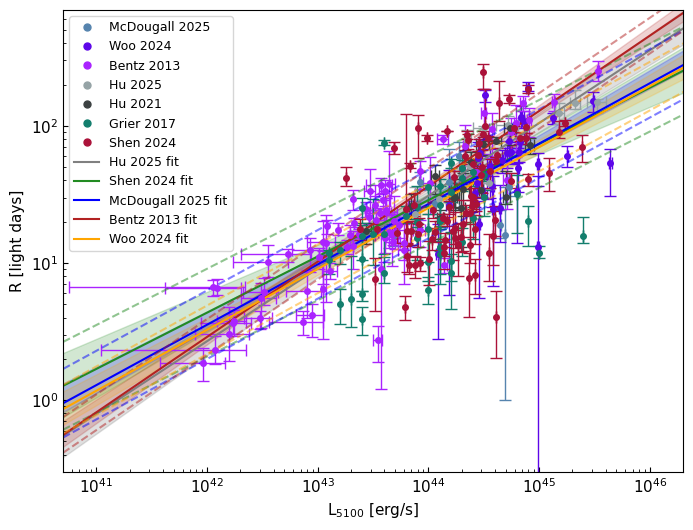

In [46]:
cursor = objects.find({'$and':[{'properties.lags.H_beta': {'$exists': True}}, {'properties.L5100.McDougall2025': {'$exists': True}}]})

lag_McDougall2025 = []
lag_error_plus_McDougall2025 = []
lag_error_minus_McDougall2025 = []
lag_grade_McDougall2025 = []

L_McDougall2025 = []
L_error_McDougall2025 = []

for object in cursor:
    lag, lag_error_plus, lag_error_minus, lag_grade = get_lag(object, 'H_beta', mode = 'simple', source ='McDougall2025')
    L, L_error = get_luminosity(object, 'L5100',mode = 'simple', source = 'McDougall2025')
    lag_McDougall2025.append(lag)
    lag_error_plus_McDougall2025.append(lag_error_plus)
    lag_error_minus_McDougall2025.append(lag_error_minus)
    lag_grade_McDougall2025.append(lag_grade)
    L_McDougall2025.append(L / 1e44)
    L_error_McDougall2025.append(L_error / 1e44)

cursor = objects.find({'$and':[{'properties.lags.H_beta': {'$exists': True}}, {'properties.L5100.Hu2025': {'$exists': True}}]})

lag_Hu2025 = []
lag_error_plus_Hu2025 = []
lag_error_minus_Hu2025 = []
lag_grade_Hu2025 = []

L_Hu2025 = []
L_error_Hu2025 = []

for object in cursor:
    lag, lag_error_plus, lag_error_minus, lag_grade = get_lag(object, 'H_beta',mode = 'simple', source = 'Hu2025')
    L, L_error = get_luminosity(object, 'L5100',mode = 'simple', source = 'Hu2025')
    lag_Hu2025.append(lag)
    lag_error_plus_Hu2025.append(lag_error_plus)
    lag_error_minus_Hu2025.append(lag_error_minus)
    lag_grade_Hu2025.append(lag_grade)
    L_Hu2025.append(L / 1e44)
    L_error_Hu2025.append(L_error / 1e44)

cursor = objects.find({'$and':[{'properties.lags.H_beta': {'$elemMatch': {'source': link_finder('Shen2024')}}},{'properties.L5100.Shen2024': {'$exists': True}}]})

lag_Shen2024 = []
lag_error_plus_Shen2024 = []
lag_error_minus_Shen2024 = []
lag_grade_Shen2024 = []

L_Shen2024 = []
L_error_Shen2024 = []

for object in cursor:
    lag, lag_error_plus, lag_error_minus, lag_grade = get_lag(object, 'H_beta',mode = 'simple', source = 'Shen2024')
    L, L_error = get_luminosity(object, 'L5100',mode = 'simple', source = 'Shen2024')
    lag_Shen2024.append(lag)
    lag_error_plus_Shen2024.append(lag_error_plus)
    lag_error_minus_Shen2024.append(lag_error_minus)
    lag_grade_Shen2024.append(lag_grade)
    L_Shen2024.append(L / 1e44)
    L_error_Shen2024.append(L_error / 1e44)

index_1 = [i for i, e in enumerate(lag_grade_Shen2024) if e ==1]
index_2 = [i for i, e in enumerate(lag_grade_Shen2024) if e ==2]
index_3 = [i for i, e in enumerate(lag_grade_Shen2024) if e ==3]
index_4 = [i for i, e in enumerate(lag_grade_Shen2024) if e ==4]
index_5 = [i for i, e in enumerate(lag_grade_Shen2024) if e ==5]
L_1_Shen2024 = np.array([L_Shen2024[i] for i in index_1])
L_2_Shen2024 = np.array([L_Shen2024[i] for i in index_2])
L_3_Shen2024 = np.array([L_Shen2024[i] for i in index_3])
L_4_Shen2024 = np.array([L_Shen2024[i] for i in index_4])
L_5_Shen2024 = np.array([L_Shen2024[i] for i in index_5])
L_1_error_Shen2024 = np.array([L_error_Shen2024[i] for i in index_1])
L_2_error_Shen2024 = np.array([L_error_Shen2024[i] for i in index_2])
L_3_error_Shen2024 = np.array([L_error_Shen2024[i] for i in index_3])
L_4_error_Shen2024 = np.array([L_error_Shen2024[i] for i in index_4])
L_5_error_Shen2024 = np.array([L_error_Shen2024[i] for i in index_5])
lag_1_Shen2024 = np.array([lag_Shen2024[i] for i in index_1])
lag_2_Shen2024 = np.array([lag_Shen2024[i] for i in index_2])
lag_3_Shen2024 = np.array([lag_Shen2024[i] for i in index_3])
lag_4_Shen2024 = np.array([lag_Shen2024[i] for i in index_4])
lag_5_Shen2024 = np.array([lag_Shen2024[i] for i in index_5])
lag_error_plus_1_Shen2024 = np.array([lag_error_plus_Shen2024[i] for i in index_1])
lag_error_plus_2_Shen2024 = np.array([lag_error_plus_Shen2024[i] for i in index_2])
lag_error_plus_3_Shen2024 = np.array([lag_error_plus_Shen2024[i] for i in index_3])
lag_error_plus_4_Shen2024 = np.array([lag_error_plus_Shen2024[i] for i in index_4])
lag_error_plus_5_Shen2024 = np.array([lag_error_plus_Shen2024[i] for i in index_5])
lag_error_minus_1_Shen2024 = np.array([lag_error_minus_Shen2024[i] for i in index_1])
lag_error_minus_2_Shen2024 = np.array([lag_error_minus_Shen2024[i] for i in index_2])
lag_error_minus_3_Shen2024 = np.array([lag_error_minus_Shen2024[i] for i in index_3])
lag_error_minus_4_Shen2024 = np.array([lag_error_minus_Shen2024[i] for i in index_4])
lag_error_minus_5_Shen2024 = np.array([lag_error_minus_Shen2024[i] for i in index_5])

cursor = objects.find({'$and':[{'properties.lags.H_beta': {'$exists': True}}, {'properties.L5100.Woo2024': {'$exists': True}}]})

lag_Woo2024 = []
lag_error_plus_Woo2024 = []
lag_error_minus_Woo2024 = []
lag_grade_Woo2024 = []

L_Woo2024 = []
L_error_Woo2024 = []

for object in cursor:
    lag, lag_error_plus, lag_error_minus, lag_grade = get_lag(object, 'H_beta',mode = 'simple', source = 'Woo2024')
    L, L_error = get_luminosity(object, 'L5100',mode = 'simple', source = 'Woo2024')
    lag_Woo2024.append(lag)
    lag_error_plus_Woo2024.append(lag_error_plus)
    lag_error_minus_Woo2024.append(lag_error_minus)
    lag_grade_Woo2024.append(lag_grade)
    L_Woo2024.append(L / 1e44)
    L_error_Woo2024.append(L_error / 1e44)


cursor = objects.find({'$and':[{'properties.lags.H_beta': {'$exists': True}}, {'properties.L5100.Bentz2013': {'$exists': True}}]})

lag_Bentz2013 = []
lag_error_plus_Bentz2013 = []
lag_error_minus_Bentz2013 = []
lag_grade_Bentz2013 = []

L_Bentz2013 = []
L_error_Bentz2013 = []

for object in cursor:
    lag, lag_error_plus, lag_error_minus, lag_grade = get_lag(object, 'H_beta',mode = 'simple', source = 'Bentz2013')
    L, L_error = get_luminosity(object, 'L5100',mode = 'simple', source = 'Bentz2013')
    if len(lag) != len(L):
        print(object.get('names', {})[0])
    for i in range(len(lag)):
        lag_Bentz2013.append(lag[i])
        lag_error_plus_Bentz2013.append(lag_error_plus[i])
        lag_error_minus_Bentz2013.append(lag_error_minus[i])
        lag_grade_Bentz2013.append(lag_grade[i])
        L_Bentz2013.append(L[i] / 1e44)
        L_error_Bentz2013.append(L_error[i] / 1e44)

cursor = objects.find({'$and':[{'properties.lags.H_beta': {'$exists': True}}, {'properties.L5100.Hu2021': {'$exists': True}}]})

lag_Hu2021 = []
lag_error_plus_Hu2021 = []
lag_error_minus_Hu2021 = []
lag_grade_Hu2021 = []

L_Hu2021 = []
L_error_Hu2021 = []

for object in cursor:
    lag, lag_error_plus, lag_error_minus, lag_grade = get_lag(object, 'H_beta',mode = 'simple', source = 'Hu2021')
    L, L_error = get_luminosity(object, 'L5100',mode = 'simple', source = 'Hu2021')
    lag_Hu2021.append(lag)
    lag_error_plus_Hu2021.append(lag_error_plus)
    lag_error_minus_Hu2021.append(lag_error_minus)
    lag_grade_Hu2021.append(lag_grade)
    L_Hu2021.append(L / 1e44)
    L_error_Hu2021.append(L_error / 1e44)

cursor = objects.find({'$and':[{'properties.lags.H_beta': {'$elemMatch': {'source': link_finder('Grier2017')}}},{'properties.L5100.Grier2017': {'$exists': True}}]})

lag_Grier2017 = []
lag_error_plus_Grier2017 = []
lag_error_minus_Grier2017 = []
lag_grade_Grier2017 = []

L_Grier2017 = []
L_error_Grier2017 = []

for object in cursor:
    lag, lag_error_plus, lag_error_minus, lag_grade = get_lag(object, 'H_beta',mode = 'simple', source = 'Grier2017')
    L, L_error = get_luminosity(object, 'L5100',mode = 'simple', source = 'Grier2017')
    lag_Grier2017.append(lag)
    lag_error_plus_Grier2017.append(lag_error_plus)
    lag_error_minus_Grier2017.append(lag_error_minus)
    lag_grade_Grier2017.append(lag_grade)
    L_Grier2017.append(L / 1e44)
    L_error_Grier2017.append(L_error / 1e44)

#Shen24 fitparameter
x = np.linspace(5e40, 1e47, 10000) / 1e44
def fit(x, a, b):
    return 10**a*x**b
#Hu25 fitparameter
y_min_Hu25, y_max_Hu25 = shaded_fit(1.49,0.03,0.03,0.53,0.04,0.04,x)
def model(x, A, b, c, x0):
    return A * x ** b * (1 + x/x0)**-c


y_med_Shen24, y_low_Shen24, y_high_Shen24, y_s_lo_Shen24, y_s_hi_Shen24 = rl_model_with_errors(
    x, 0.41, 0.07, 0.07, 1.458, 0.038, 0.038, 0.32)
y_med_McDougall, y_low_McDougall, y_high_McDougall, y_s_lo_McDougall, y_s_hi_McDougall = rl_model_with_errors(
    x, 0.44, 0.02, 0.04, 1.43, 0.02, 0.04, 0.25)
y_med_Bentz, y_low_Bentz, y_high_Bentz, y_s_lo_Bentz, y_s_hi_Bentz = rl_model_with_errors(
    x, 0.549, 0.027, 0.028, 1.559, 0.024, 0.024, 0.13)
y_med_Woo, y_low_Woo, y_high_Woo, y_s_lo_Woo, y_s_hi_Woo = rl_model_with_errors(
    x, 0.444, 0.035, 0.036, 1.401, 0.034, 0.034, 0.177)

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import LogFormatterMathtext

L_Shen2024 = np.concatenate([L_1_Shen2024, L_2_Shen2024, L_3_Shen2024, L_4_Shen2024, L_5_Shen2024])
L_error_Shen2024 = np.concatenate([L_1_error_Shen2024, L_2_error_Shen2024, L_3_error_Shen2024, L_4_error_Shen2024, L_5_error_Shen2024])
lag_Shen2024 = np.concatenate([lag_1_Shen2024, lag_2_Shen2024, lag_3_Shen2024, lag_4_Shen2024, lag_5_Shen2024])
lag_error_plus_Shen2024 = np.concatenate([lag_error_plus_1_Shen2024, lag_error_plus_2_Shen2024, lag_error_plus_3_Shen2024, lag_error_plus_4_Shen2024, lag_error_plus_5_Shen2024])
lag_error_minus_Shen2024 = np.concatenate([lag_error_minus_1_Shen2024, lag_error_minus_2_Shen2024, lag_error_minus_3_Shen2024, lag_error_minus_4_Shen2024, lag_error_minus_5_Shen2024])


plt.figure(figsize = (8,6))#/ 1.618))
#plt.figure(figsize = (10, 10 / 1.618))
plt.xscale('log')
plt.yscale('log')
plt.errorbar(L_McDougall2025, lag_McDougall2025 ,xerr = L_error_McDougall2025,yerr = [lag_error_minus_McDougall2025, lag_error_plus_McDougall2025] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 4, ms = 4, label = '_nolegend_', color = 'xkcd:off blue')
plt.plot([],[],'o', ms = 5, label = 'McDougall 2025', color = 'xkcd:off blue')
plt.errorbar(L_Woo2024, lag_Woo2024 ,xerr = L_error_Woo2024,yerr = [lag_error_minus_Woo2024, lag_error_plus_Woo2024] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 4, ms = 4, label = '_nolegend_',color = 'xkcd:Blue violet')
plt.plot([],[],'o', ms = 5, label = 'Woo 2024', color = 'xkcd:Blue violet')
plt.errorbar(L_Bentz2013, lag_Bentz2013 ,xerr = L_error_Bentz2013,yerr = [lag_error_minus_Bentz2013, lag_error_plus_Bentz2013] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 4, ms = 4, label = '_nolegend_', color = 'xkcd:Electric purple')
plt.plot([],[],'o', ms = 5, label = 'Bentz 2013', color = 'xkcd:Electric purple')
plt.errorbar(L_Hu2025, lag_Hu2025 ,xerr = L_error_Hu2025,yerr = [lag_error_minus_Hu2025, lag_error_plus_Hu2025] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 4, ms = 4, label = '_nolegend_', color = 'xkcd:Cool Grey')
plt.plot([],[],'o', ms = 5, label = 'Hu 2025', color = 'xkcd:Cool Grey')
plt.errorbar(L_Hu2021, lag_Hu2021 ,xerr = L_error_Hu2021,yerr = [lag_error_minus_Hu2021, lag_error_plus_Hu2021] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 4, ms = 4, label = '_nolegend_', color = 'xkcd:Charcoal Grey')
plt.plot([],[],'o', ms = 5, label = 'Hu 2021', color = 'xkcd:Charcoal Grey')
plt.errorbar(L_Grier2017, lag_Grier2017 ,xerr = L_error_Grier2017,yerr = [lag_error_minus_Grier2017, lag_error_plus_Grier2017] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 4, ms = 4, label = '_nolegend_', color = 'xkcd:Blue green')
plt.plot([],[],'o', ms = 5, label = 'Grier 2017', color = 'xkcd:Blue green')
plt.errorbar(L_Shen2024, lag_Shen2024 ,xerr = L_error_Shen2024,yerr = [lag_error_minus_Shen2024, lag_error_plus_Shen2024] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 4, ms = 4, label = '_nolegend_', color = 'xkcd:Rouge')
plt.plot([],[],'o', ms = 5, label = 'Shen 2024', color = 'xkcd:Rouge')
plt.xlabel(r'L$_{5100}$ [erg/s]')
plt.ylabel('R [light days]')
plt.fill_between(x, y_min_Hu25, y_max_Hu25, alpha = 0.25, color = 'gray')
plt.plot(x, fit(x, 1.49, 0.53), label = 'Hu 2025 fit', color = 'gray')
plt.fill_between(x, y_low_Shen24, y_high_Shen24, color='forestgreen', alpha=0.2)
plt.plot(x, y_med_Shen24, color='forestgreen', label = 'Shen 2024 fit')
plt.plot(x, y_s_lo_Shen24, color = 'forestgreen', ls = '--', alpha = 0.5)
plt.plot(x, y_s_hi_Shen24, color = 'forestgreen', ls = '--', alpha = 0.5)
plt.fill_between(x, y_low_McDougall, y_high_McDougall, color='blue', alpha=0.2)
plt.plot(x, y_med_McDougall, color='blue', label = 'McDougall 2025 fit')
plt.plot(x, y_s_lo_McDougall, color = 'blue', ls = '--', alpha = 0.5)
plt.plot(x, y_s_hi_McDougall, color = 'blue', ls = '--', alpha = 0.5)
plt.fill_between(x, y_low_Bentz, y_high_Bentz, color='firebrick', alpha=0.2)
plt.plot(x, y_med_Bentz, color='firebrick', label = 'Bentz 2013 fit')
plt.plot(x, y_s_lo_Bentz, color = 'firebrick', ls = '--', alpha = 0.5)
plt.plot(x, y_s_hi_Bentz, color = 'firebrick', ls = '--', alpha = 0.5)
plt.fill_between(x, y_low_Woo, y_high_Woo, color='orange', alpha=0.2)
plt.plot(x, y_med_Woo, color='orange', label = 'Woo 2024 fit')
plt.plot(x, y_s_lo_Woo, color = 'orange', ls = '--', alpha = 0.5)
plt.plot(x, y_s_hi_Woo, color = 'orange', ls = '--', alpha = 0.5)
plt.legend(loc = 'best')
plt.tick_params(which='major', direction='in')
plt.tick_params(which='minor', direction='in')
plt.ylim(3e-1,7e2)
plt.xlim(5e-4,2e2)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: rf'$10^{{{int(np.log10(val*1e44))}}}$')
)
plt.savefig('R_L_paper_figures\R_L_H_beta.pdf', bbox_inches = 'tight', dpi = 600)#pad_inches = 0.02)

### Bias of the ideal ICCF setup

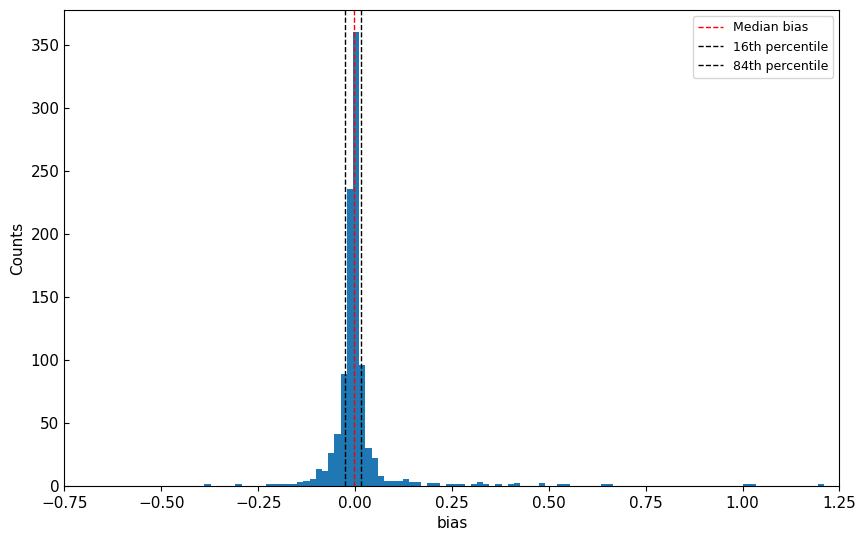

In [47]:
files = glob(f'A:\\UniDokumente\\Projektpraktikum\\ICCF_Bias\\variation_2\\result_*.npz')


data = np.load(f'A:\\UniDokumente\\Projektpraktikum\\ICCF_Bias\\variation_2\\lags.npz')
lags = data['lags']
fraction = lags / 50 -1 # 50 is true lag
low = np.percentile(fraction, 16)
high = np.percentile(fraction, 84)


plt.figure(figsize = (10, 10 / 1.618))
#plt.title('Bias histogram for rmax = 0.8, t_unit = 0.8 * 1/24')
plt.hist(fraction, 100)
plt.axvline(np.median(fraction), label = 'Median bias', color = 'red', ls = 'dashed', lw = 1)
plt.axvline(low, label = '16th percentile', color = 'black', ls = 'dashed', lw = 1)
plt.axvline(high, label = '84th percentile', color = 'black', ls = 'dashed', lw = 1)
plt.legend(loc = 'best')
plt.xlabel('bias')
plt.ylabel('Counts')
plt.xlim(-0.75,1.25)
plt.tick_params(axis = 'x', direction = 'out')
plt.tick_params(axis = 'y', direction = 'in')
plt.savefig('R_L_paper_figures\iccf_bias_ideal_setup.pdf', bbox_inches = 'tight', dpi = 600)


### The different trials using detrending and shit like that

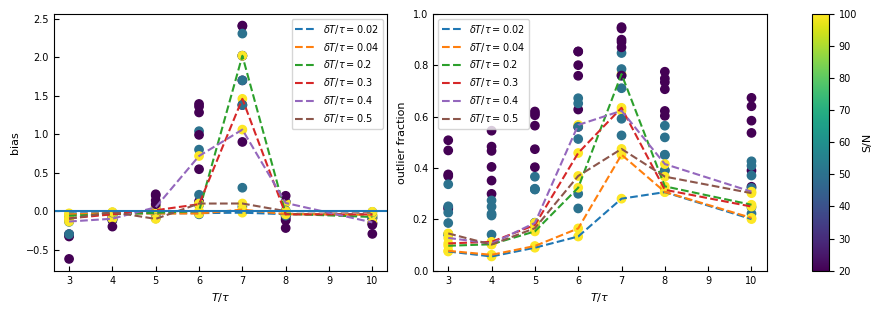

In [ ]:
data = pd.read_csv(r'A:\\UniDokumente\\Projektpraktikum\\ICCF_Trial_3\\result_summary.csv')



fig = plt.figure(figsize=(10, 10/3))

gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
cax = fig.add_subplot(gs[2])
pos = ax1.scatter( data['T/tau'],data['bias'] , c = data['SN'], norm = 'linear', cmap = 'viridis')
for value in np.unique(data['t/tau']):
    for v2 in np.unique(data['SN']):
        if v2 == 100:
            mask = (data['t/tau'] == value) & (data['SN'] == v2)
            
            x_group = data['T/tau'][mask]
            y_group = data['bias'][mask]
            ax1.plot(
                x_group,
                y_group,
                linestyle="--",
                marker=None,
                label = f'$\delta T / \\tau =${value}'
            )
ax1.legend(loc = 'best')
ax1.set(xlabel = '$T/\\tau$', ylabel = 'bias')
ax1.axhline(0)
ax1.tick_params(which='major', direction='in')

ax2.scatter( data['T/tau'],data['outlier_fraction'] , c = data['SN'], norm = 'linear', cmap = 'viridis')
for value in np.unique(data['t/tau']):
    for v2 in np.unique(data['SN']):
        if v2 == 100:
            mask = (data['t/tau'] == value) & (data['SN'] == v2)
            
            sorter = np.argsort(data['T/tau'][mask].to_numpy())

            x_group = data['T/tau'][mask].to_numpy()[sorter]
            y_group = data['outlier_fraction'][mask].to_numpy()[sorter]
            ax2.plot(
                x_group,
                y_group,
                linestyle="--",
                marker=None,
                label = f'$\delta T / \\tau =${value}'
            )
ax2.legend(loc = 'best')
ax2.set(xlabel = '$T/\\tau$', ylabel = 'outlier fraction', ylim = (0,1))
fig.colorbar(pos, cax = cax, label = 'S/N')
ax2.tick_params(which='major', direction='in')
plt.savefig(r'R_L_paper_figures\result_trial_1.pdf', bbox_inches = 'tight', pad_inches = 0.02)


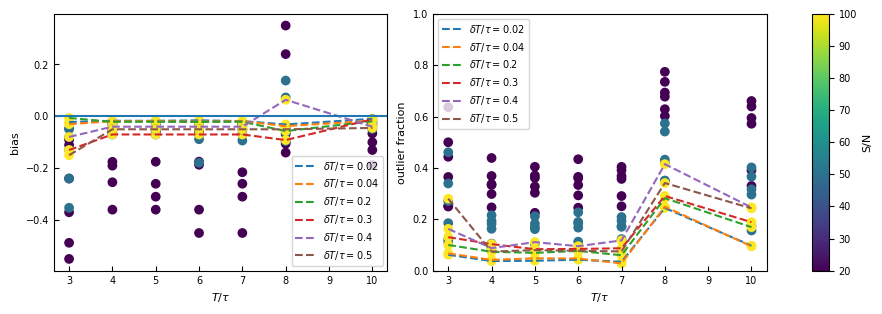

In [23]:
data = pd.read_csv(r'A:\\UniDokumente\\Projektpraktikum\\ICCF_Trial_12\\result_summary.csv')

fig = plt.figure(figsize=(10, 10/3))

gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
cax = fig.add_subplot(gs[2])
pos = ax1.scatter( data['T/tau'],data['bias'] , c = data['SN'], norm = 'linear', cmap = 'viridis')
for value in np.unique(data['t/tau']):
    for v2 in np.unique(data['SN']):
        if v2 == 100:
            mask = (data['t/tau'] == value) & (data['SN'] == v2)
            
            x_group = data['T/tau'][mask]
            y_group = data['bias'][mask]
            ax1.plot(
                x_group,
                y_group,
                linestyle="--",
                marker=None,
                label = f'$\delta T / \\tau =${value}'
            )
ax1.legend(loc = 'best')
ax1.set(xlabel = '$T/\\tau$', ylabel = 'bias')
ax1.axhline(0)
ax1.tick_params(which='major', direction='in')

ax2.scatter( data['T/tau'],data['outlier_fraction'] , c = data['SN'], norm = 'linear', cmap = 'viridis')
for value in np.unique(data['t/tau']):
    for v2 in np.unique(data['SN']):
        if v2 == 100:
            mask = (data['t/tau'] == value) & (data['SN'] == v2)
            
            sorter = np.argsort(data['T/tau'][mask].to_numpy())

            x_group = data['T/tau'][mask].to_numpy()[sorter]
            y_group = data['outlier_fraction'][mask].to_numpy()[sorter]
            ax2.plot(
                x_group,
                y_group,
                linestyle="--",
                marker=None,
                label = f'$\delta T / \\tau =${value}'
            )
ax2.legend(loc = 'upper left')
ax2.set(xlabel = '$T/\\tau$', ylabel = 'outlier fraction', ylim = (0,1))
fig.colorbar(pos, cax = cax, label = 'S/N')
ax2.tick_params(which='major', direction='in')
plt.savefig(r'R_L_paper_figures\result_trial_2.pdf', bbox_inches = 'tight', pad_inches = 0.02)


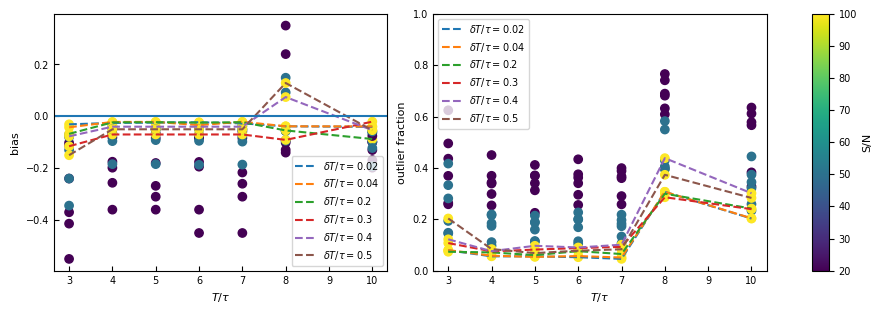

In [24]:
data = pd.read_csv(r'A:\\UniDokumente\\Projektpraktikum\\ICCF_Trial_13\\result_summary.csv')



fig = plt.figure(figsize=(10, 10/3))

gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
cax = fig.add_subplot(gs[2])
pos = ax1.scatter( data['T/tau'],data['bias'] , c = data['SN'], norm = 'linear', cmap = 'viridis')
for value in np.unique(data['t/tau']):
    for v2 in np.unique(data['SN']):
        if v2 == 100:
            mask = (data['t/tau'] == value) & (data['SN'] == v2)
            
            x_group = data['T/tau'][mask]
            y_group = data['bias'][mask]
            ax1.plot(
                x_group,
                y_group,
                linestyle="--",
                marker=None,
                label = f'$\delta T / \\tau =${value}'
            )
ax1.legend(loc = 'best')
ax1.set(xlabel = '$T/\\tau$', ylabel = 'bias')
ax1.axhline(0)
ax1.tick_params(which='major', direction='in')

ax2.scatter( data['T/tau'],data['outlier_fraction'] , c = data['SN'], norm = 'linear', cmap = 'viridis')
for value in np.unique(data['t/tau']):
    for v2 in np.unique(data['SN']):
        if v2 == 100:
            mask = (data['t/tau'] == value) & (data['SN'] == v2)
            
            sorter = np.argsort(data['T/tau'][mask].to_numpy())

            x_group = data['T/tau'][mask].to_numpy()[sorter]
            y_group = data['outlier_fraction'][mask].to_numpy()[sorter]
            ax2.plot(
                x_group,
                y_group,
                linestyle="--",
                marker=None,
                label = f'$\delta T / \\tau =${value}'
            )
ax2.legend(loc = 'upper left')
ax2.set(xlabel = '$T/\\tau$', ylabel = 'outlier fraction', ylim = (0,1))
fig.colorbar(pos, cax = cax, label = 'S/N')
ax2.tick_params(which='major', direction='in')
plt.savefig(r'R_L_paper_figures\result_trial_3.pdf', bbox_inches = 'tight', pad_inches = 0.02)


### Routine to redo the plots of the fitting process

Entire sample

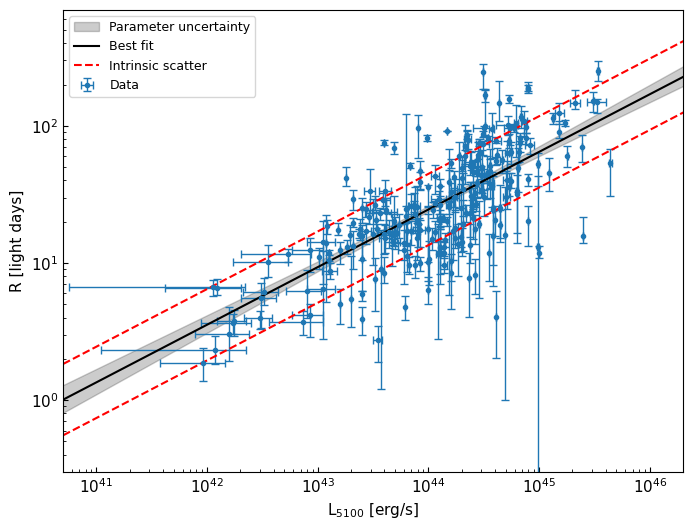

In [72]:
data = pd.read_csv(r'A:\\UniDokumente\\Projektpraktikum\\check_db_sim\\results.csv', header = 0)

fit_data = data

names = fit_data['name'].to_list()
sources = fit_data['source'].to_list()
rep_lags = fit_data['reported lag'].to_list()
rep_lum = fit_data['luminosity'].to_list()

lags = []
lags_error_plus = []
lags_error_minus = []
lum = []
lum_error = []

for i in range(len(names)):
    if sources[i] == 'Bentz2013':
        cursor = objects.find_one({'names': names[i]})
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        main_reference = corr_entry['main reference']
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])
        lum_entries = cursor.get('properties').get('L5100').get('Bentz2013')
        for j in range(len(lum_entries)):
            curr_entry = lum_entries[j]
            if np.round(curr_entry['value'], -42) == np.round(rep_lum[i], -42):
                corr_indx = j
        corr_entry = lum_entries[corr_indx]
        lum.append(corr_entry['value'] / 1e44)
        lum_error.append(corr_entry['error'] / 1e44)
    else:
        cursor = objects.find_one({'names': names[i]})
        L, L_error = get_luminosity(cursor, 'L5100', mode = 'simple', source = sources[i])
        lum.append(L / 1e44)
        lum_error.append(L_error / 1e44)
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])


x_plot = np.linspace(5e40, 1e47, 10000) / 1e44

y_med, y_low, y_high, y_s_lo, y_s_hi = rl_model_with_errors(
    x_plot, 0.42, 0.03, 0.03, 1.39, 0.02, 0.02, 0.26)



#plt.figure(figsize = (10, 10 / 1.618))
plt.figure(figsize = (8,6))
plt.xscale('log')
plt.yscale('log')
plt.errorbar(lum, lags ,xerr =lum_error ,yerr = [lags_error_minus, lags_error_plus] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Data')
plt.fill_between(x_plot, y_low, y_high, color='black', alpha=0.2, label = 'Parameter uncertainty')
plt.plot(x_plot, y_med, color='black', label = 'Best fit')
plt.plot(x_plot, y_s_lo, color = 'red', ls = '--', alpha = 1, label = 'Intrinsic scatter')
plt.plot(x_plot, y_s_hi, color = 'red', ls = '--', alpha = 1)
plt.xlabel(r'L$_{5100}$ [erg/s]')
plt.ylabel('R [light days]')
#plt.title(r'R-L $H_\beta$ for all categories')
plt.tick_params(which='major', direction='in')
plt.tick_params(which='minor', direction='in')
plt.legend(loc = 'upper left')
plt.ylim(3e-1,7e2)
plt.xlim(5e-4,2e2)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: rf'$10^{{{int(np.log10(val*1e44))}}}$')
)
plt.savefig(r'R_L_paper_figures\fit_cat_all.pdf', bbox_inches = 'tight', dpi = 600)

Initial setup, 0+1+2

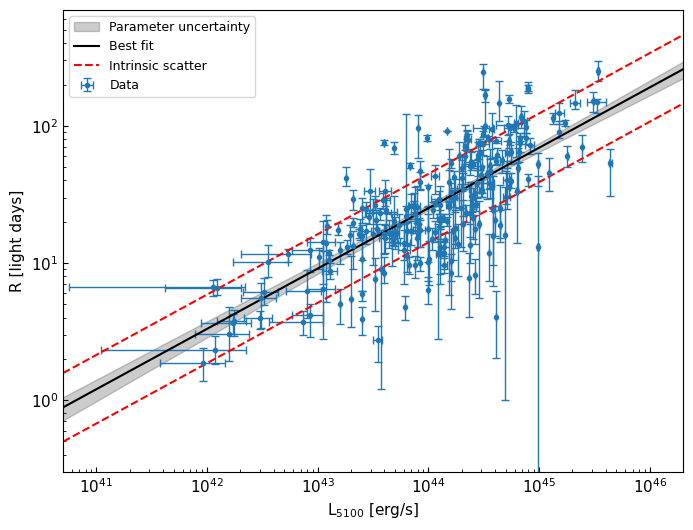

In [73]:
data = pd.read_csv(r'A:\\UniDokumente\\Projektpraktikum\\check_db_sim\\results.csv', header = 0)

fit_data = data.mask(data['flag'] == 3).dropna()


names = fit_data['name'].to_list()
sources = fit_data['source'].to_list()
rep_lags = fit_data['reported lag'].to_list()
rep_lum = fit_data['luminosity'].to_list()

lags = []
lags_error_plus = []
lags_error_minus = []
lum = []
lum_error = []

for i in range(len(names)):
    if sources[i] == 'Bentz2013':
        cursor = objects.find_one({'names': names[i]})
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        main_reference = corr_entry['main reference']
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])
        lum_entries = cursor.get('properties').get('L5100').get('Bentz2013')
        for j in range(len(lum_entries)):
            curr_entry = lum_entries[j]
            if np.round(curr_entry['value'], -42) == np.round(rep_lum[i], -42):
                corr_indx = j
        corr_entry = lum_entries[corr_indx]
        lum.append(corr_entry['value'] / 1e44)
        lum_error.append(corr_entry['error'] / 1e44)
    else:
        cursor = objects.find_one({'names': names[i]})
        L, L_error = get_luminosity(cursor, 'L5100', mode = 'simple', source = sources[i])
        lum.append(L / 1e44)
        lum_error.append(L_error / 1e44)
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])


x_plot = np.linspace(5e40, 1e47, 1000) / 1e44

y_med, y_low, y_high, y_s_lo, y_s_hi = rl_model_with_errors(
    x_plot, 0.44, 0.03, 0.02, 1.40, 0.02, 0.02, 0.25)


plt.figure(figsize = (8,6))
plt.xscale('log')
plt.yscale('log')
plt.errorbar(lum, lags ,xerr =lum_error ,yerr = [lags_error_minus, lags_error_plus] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Data')
plt.fill_between(x_plot, y_low, y_high, color='black', alpha=0.2, label = 'Parameter uncertainty')
plt.plot(x_plot, y_med, color='black', label = 'Best fit')
plt.plot(x_plot, y_s_lo, color = 'red', ls = '--', alpha = 1, label = 'Intrinsic scatter')
plt.plot(x_plot, y_s_hi, color = 'red', ls = '--', alpha = 1)
plt.xlabel(r'L$_{5100}$ [erg/s]')
plt.ylabel('R [light days]')
#plt.title(r'R-L $H_\beta$ for all categories')
plt.tick_params(which='major', direction='in')
plt.tick_params(which='minor', direction='in')
plt.legend(loc = 'upper left')
plt.ylim(3e-1,7e2)
plt.xlim(5e-4,2e2)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: rf'$10^{{{int(np.log10(val*1e44))}}}$')
)
plt.savefig(r'R_L_paper_figures\fit_cat_012.pdf', bbox_inches = 'tight', dpi = 600)

Initial setup 0+1

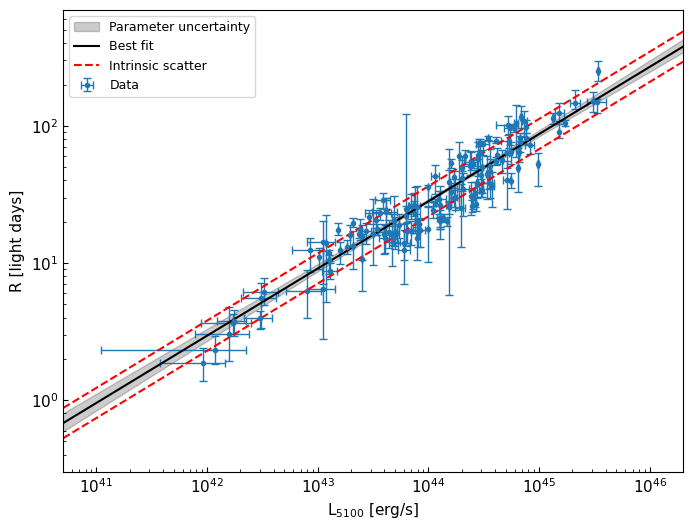

In [74]:
data = pd.read_csv(r'A:\\UniDokumente\\Projektpraktikum\\check_db_sim\\results.csv', header = 0)

fit_data = data.mask(data['flag'] == 3).dropna()
fit_data = fit_data.mask(data['flag'] == 2).dropna()

names = fit_data['name'].to_list()
sources = fit_data['source'].to_list()
rep_lags = fit_data['reported lag'].to_list()
rep_lum = fit_data['luminosity'].to_list()

lags = []
lags_error_plus = []
lags_error_minus = []
lum = []
lum_error = []

for i in range(len(names)):
    if sources[i] == 'Bentz2013':
        cursor = objects.find_one({'names': names[i]})
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        main_reference = corr_entry['main reference']
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])
        lum_entries = cursor.get('properties').get('L5100').get('Bentz2013')
        for j in range(len(lum_entries)):
            curr_entry = lum_entries[j]
            if np.round(curr_entry['value'], -42) == np.round(rep_lum[i], -42):
                corr_indx = j
        corr_entry = lum_entries[corr_indx]
        lum.append(corr_entry['value'] / 1e44)
        lum_error.append(corr_entry['error'] / 1e44)
    else:
        cursor = objects.find_one({'names': names[i]})
        L, L_error = get_luminosity(cursor, 'L5100', mode = 'simple', source = sources[i])
        lum.append(L / 1e44)
        lum_error.append(L_error / 1e44)
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])


x_plot = np.linspace(5e40, 1e47, 1000) / 1e44

y_med, y_low, y_high, y_s_lo, y_s_hi = rl_model_with_errors(
    x_plot, 0.49, 0.02, 0.02, 1.45, 0.01, 0.01, 0.11)


plt.figure(figsize = (8,6))
plt.xscale('log')
plt.yscale('log')
plt.errorbar(lum, lags ,xerr =lum_error ,yerr = [lags_error_minus, lags_error_plus] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Data')
plt.fill_between(x_plot, y_low, y_high, color='black', alpha=0.2, label = 'Parameter uncertainty')
plt.plot(x_plot, y_med, color='black', label = 'Best fit')
plt.plot(x_plot, y_s_lo, color = 'red', ls = '--', alpha = 1, label = 'Intrinsic scatter')
plt.plot(x_plot, y_s_hi, color = 'red', ls = '--', alpha = 1)
plt.xlabel(r'L$_{5100}$ [erg/s]')
plt.ylabel('R [light days]')
#plt.title(r'R-L $H_\beta$ for all categories')
plt.tick_params(which='major', direction='in')
plt.tick_params(which='minor', direction='in')
plt.legend(loc = 'upper left')
plt.ylim(3e-1,7e2)
plt.xlim(5e-4,2e2)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: rf'$10^{{{int(np.log10(val*1e44))}}}$')
)
plt.savefig(r'R_L_paper_figures\fit_cat_01.pdf', bbox_inches = 'tight', dpi = 600)

Initial setup, only 0

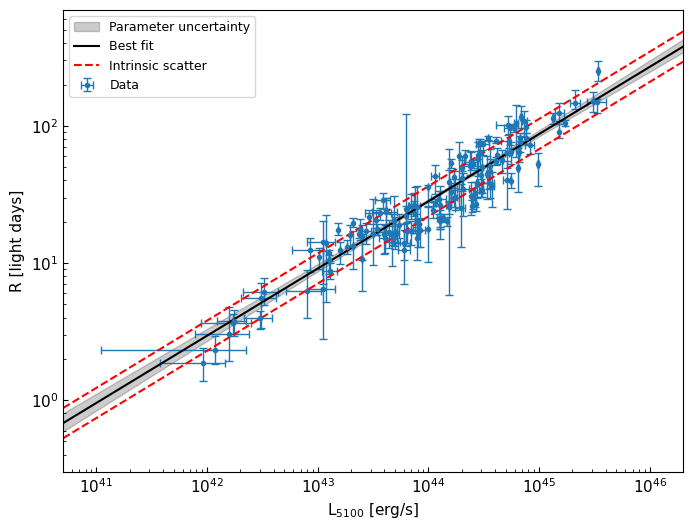

In [75]:
data = pd.read_csv(r'A:\\UniDokumente\\Projektpraktikum\\check_db_sim\\results.csv', header = 0)

fit_data = data.mask(data['flag'] != 0).dropna()


names = fit_data['name'].to_list()
sources = fit_data['source'].to_list()
rep_lags = fit_data['reported lag'].to_list()
rep_lum = fit_data['luminosity'].to_list()

lags = []
lags_error_plus = []
lags_error_minus = []
lum = []
lum_error = []

for i in range(len(names)):
    if sources[i] == 'Bentz2013':
        cursor = objects.find_one({'names': names[i]})
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        main_reference = corr_entry['main reference']
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])
        lum_entries = cursor.get('properties').get('L5100').get('Bentz2013')
        for j in range(len(lum_entries)):
            curr_entry = lum_entries[j]
            if np.round(curr_entry['value'], -42) == np.round(rep_lum[i], -42):
                corr_indx = j
        corr_entry = lum_entries[corr_indx]
        lum.append(corr_entry['value'] / 1e44)
        lum_error.append(corr_entry['error'] / 1e44)
    else:
        cursor = objects.find_one({'names': names[i]})
        L, L_error = get_luminosity(cursor, 'L5100', mode = 'simple', source = sources[i])
        lum.append(L / 1e44)
        lum_error.append(L_error / 1e44)
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])


x_plot = np.linspace(5e40, 1e47, 1000) / 1e44

y_med, y_low, y_high, y_s_lo, y_s_hi = rl_model_with_errors(
    x_plot, 0.49, 0.02, 0.02, 1.45, 0.01, 0.01, 0.11)



plt.figure(figsize = (8,6))
plt.xscale('log')
plt.yscale('log')
plt.errorbar(lum, lags ,xerr =lum_error ,yerr = [lags_error_minus, lags_error_plus] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Data')
plt.fill_between(x_plot, y_low, y_high, color='black', alpha=0.2, label = 'Parameter uncertainty')
plt.plot(x_plot, y_med, color='black', label = 'Best fit')
plt.plot(x_plot, y_s_lo, color = 'red', ls = '--', alpha = 1, label = 'Intrinsic scatter')
plt.plot(x_plot, y_s_hi, color = 'red', ls = '--', alpha = 1)
plt.xlabel(r'L$_{5100}$ [erg/s]')
plt.ylabel('R [light days]')
#plt.title(r'R-L $H_\beta$ for all categories')
plt.tick_params(which='major', direction='in')
plt.tick_params(which='minor', direction='in')
plt.legend(loc = 'upper left')
plt.ylim(3e-1,7e2)
plt.xlim(5e-4,2e2)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: rf'$10^{{{int(np.log10(val*1e44))}}}$')
)
plt.savefig(r'R_L_paper_figures\fit_cat_0.pdf', bbox_inches = 'tight', dpi = 600)

Strict thresholds

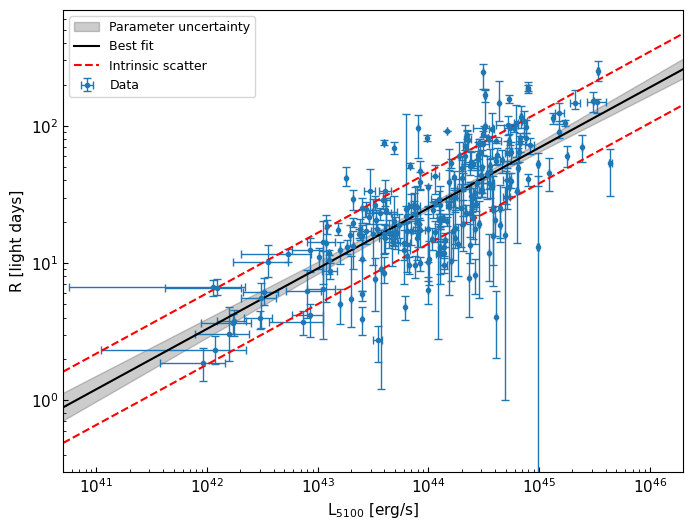

In [76]:
data = pd.read_csv(r'A:\\UniDokumente\\Projektpraktikum\\check_db_sim\\results_2.csv', header = 0)

fit_data = data.mask(data['flag'] == 3).dropna()


names = fit_data['name'].to_list()
sources = fit_data['source'].to_list()
rep_lags = fit_data['reported lag'].to_list()
rep_lum = fit_data['luminosity'].to_list()

lags = []
lags_error_plus = []
lags_error_minus = []
lum = []
lum_error = []

for i in range(len(names)):
    if sources[i] == 'Bentz2013':
        cursor = objects.find_one({'names': names[i]})
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        main_reference = corr_entry['main reference']
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])
        lum_entries = cursor.get('properties').get('L5100').get('Bentz2013')
        for j in range(len(lum_entries)):
            curr_entry = lum_entries[j]
            if np.round(curr_entry['value'], -42) == np.round(rep_lum[i], -42):
                corr_indx = j
        corr_entry = lum_entries[corr_indx]
        lum.append(corr_entry['value'] / 1e44)
        lum_error.append(corr_entry['error'] / 1e44)
    else:
        cursor = objects.find_one({'names': names[i]})
        L, L_error = get_luminosity(cursor, 'L5100', mode = 'simple', source = sources[i])
        lum.append(L / 1e44)
        lum_error.append(L_error / 1e44)
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])


x_plot = np.linspace(5e40, 1e47, 1000) / 1e44

y_med, y_low, y_high, y_s_lo, y_s_hi = rl_model_with_errors(
    x_plot, 0.44, 0.03, 0.03, 1.40, 0.02, 0.02, 0.26)



plt.figure(figsize = (8,6))
plt.xscale('log')
plt.yscale('log')
plt.errorbar(lum, lags ,xerr =lum_error ,yerr = [lags_error_minus, lags_error_plus] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Data')
plt.fill_between(x_plot, y_low, y_high, color='black', alpha=0.2, label = 'Parameter uncertainty')
plt.plot(x_plot, y_med, color='black', label = 'Best fit')
plt.plot(x_plot, y_s_lo, color = 'red', ls = '--', alpha = 1, label = 'Intrinsic scatter')
plt.plot(x_plot, y_s_hi, color = 'red', ls = '--', alpha = 1)
plt.xlabel(r'L$_{5100}$ [erg/s]')
plt.ylabel('R [light days]')
#plt.title(r'R-L $H_\beta$ for all categories')
plt.tick_params(which='major', direction='in')
plt.tick_params(which='minor', direction='in')
plt.legend(loc = 'upper left')
plt.ylim(3e-1,7e2)
plt.xlim(5e-4,2e2)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: rf'$10^{{{int(np.log10(val*1e44))}}}$')
)
plt.savefig(r'R_L_paper_figures\fit_strict_cat_012.pdf', bbox_inches = 'tight', dpi = 600)

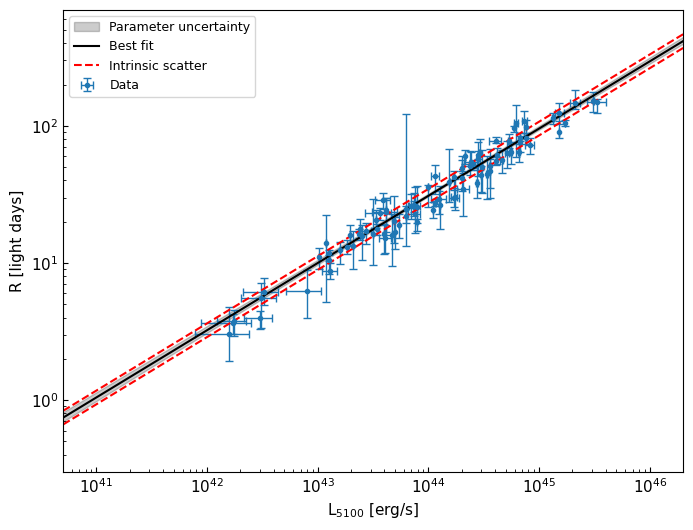

In [77]:
data = pd.read_csv(r'A:\\UniDokumente\\Projektpraktikum\\check_db_sim\\results_2.csv', header = 0)

fit_data = data.mask(data['flag'] == 3).dropna()
fit_data = fit_data.mask(data['flag'] == 2).dropna()

names = fit_data['name'].to_list()
sources = fit_data['source'].to_list()
rep_lags = fit_data['reported lag'].to_list()
rep_lum = fit_data['luminosity'].to_list()

lags = []
lags_error_plus = []
lags_error_minus = []
lum = []
lum_error = []

for i in range(len(names)):
    if sources[i] == 'Bentz2013':
        cursor = objects.find_one({'names': names[i]})
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        main_reference = corr_entry['main reference']
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])
        lum_entries = cursor.get('properties').get('L5100').get('Bentz2013')
        for j in range(len(lum_entries)):
            curr_entry = lum_entries[j]
            if np.round(curr_entry['value'], -42) == np.round(rep_lum[i], -42):
                corr_indx = j
        corr_entry = lum_entries[corr_indx]
        lum.append(corr_entry['value'] / 1e44)
        lum_error.append(corr_entry['error'] / 1e44)
    else:
        cursor = objects.find_one({'names': names[i]})
        L, L_error = get_luminosity(cursor, 'L5100', mode = 'simple', source = sources[i])
        lum.append(L / 1e44)
        lum_error.append(L_error / 1e44)
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])


x_plot = np.linspace(5e40, 1e47, 1000) / 1e44

y_med, y_low, y_high, y_s_lo, y_s_hi = rl_model_with_errors(
    x_plot, 0.49, 0.01, 0.01, 1.49, 0.01, 0.01, 0.05)


plt.figure(figsize = (8,6))
plt.xscale('log')
plt.yscale('log')
plt.errorbar(lum, lags ,xerr =lum_error ,yerr = [lags_error_minus, lags_error_plus] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Data')
plt.fill_between(x_plot, y_low, y_high, color='black', alpha=0.2, label = 'Parameter uncertainty')
plt.plot(x_plot, y_med, color='black', label = 'Best fit')
plt.plot(x_plot, y_s_lo, color = 'red', ls = '--', alpha = 1, label = 'Intrinsic scatter')
plt.plot(x_plot, y_s_hi, color = 'red', ls = '--', alpha = 1)
plt.xlabel(r'L$_{5100}$ [erg/s]')
plt.ylabel('R [light days]')
#plt.title(r'R-L $H_\beta$ for all categories')
plt.tick_params(which='major', direction='in')
plt.tick_params(which='minor', direction='in')
plt.legend(loc = 'upper left')
plt.ylim(3e-1,7e2)
plt.xlim(5e-4,2e2)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: rf'$10^{{{int(np.log10(val*1e44))}}}$')
)
plt.savefig(r'R_L_paper_figures\fit_strict_cat_01.pdf', bbox_inches = 'tight', dpi = 600)

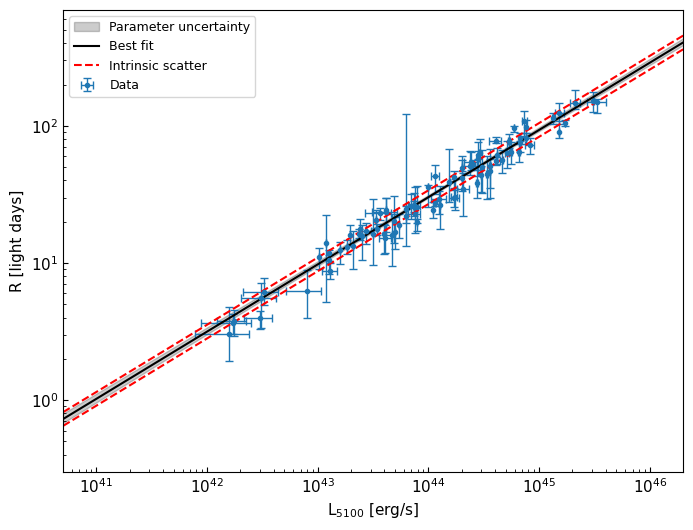

In [62]:
data = pd.read_csv(r'A:\\UniDokumente\\Projektpraktikum\\check_db_sim\\results_2.csv', header = 0)

fit_data = data.mask(data['flag'] != 0).dropna()


names = fit_data['name'].to_list()
sources = fit_data['source'].to_list()
rep_lags = fit_data['reported lag'].to_list()
rep_lum = fit_data['luminosity'].to_list()

lags = []
lags_error_plus = []
lags_error_minus = []
lum = []
lum_error = []

for i in range(len(names)):
    if sources[i] == 'Bentz2013':
        cursor = objects.find_one({'names': names[i]})
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        main_reference = corr_entry['main reference']
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])
        lum_entries = cursor.get('properties').get('L5100').get('Bentz2013')
        for j in range(len(lum_entries)):
            curr_entry = lum_entries[j]
            if np.round(curr_entry['value'], -42) == np.round(rep_lum[i], -42):
                corr_indx = j
        corr_entry = lum_entries[corr_indx]
        lum.append(corr_entry['value'] / 1e44)
        lum_error.append(corr_entry['error'] / 1e44)
    else:
        cursor = objects.find_one({'names': names[i]})
        L, L_error = get_luminosity(cursor, 'L5100', mode = 'simple', source = sources[i])
        lum.append(L / 1e44)
        lum_error.append(L_error / 1e44)
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])


x_plot = np.linspace(5e40, 1e47, 1000) / 1e44

y_med, y_low, y_high, y_s_lo, y_s_hi = rl_model_with_errors(
    x_plot, 0.49, 0.01, 0.01, 1.48, 0.01, 0.01, 0.05)

plt.figure(figsize = (8,6))
plt.xscale('log')
plt.yscale('log')
plt.errorbar(lum, lags ,xerr =lum_error ,yerr = [lags_error_minus, lags_error_plus] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Data')
plt.fill_between(x_plot, y_low, y_high, color='black', alpha=0.2, label = 'Parameter uncertainty')
plt.plot(x_plot, y_med, color='black', label = 'Best fit')
plt.plot(x_plot, y_s_lo, color = 'red', ls = '--', alpha = 1, label = 'Intrinsic scatter')
plt.plot(x_plot, y_s_hi, color = 'red', ls = '--', alpha = 1)
plt.xlabel(r'L$_{5100}$ [erg/s]')
plt.ylabel('R [light days]')
#plt.title(r'R-L $H_\beta$ for all categories')
plt.tick_params(which='major', direction='in')
plt.tick_params(which='minor', direction='in')
plt.legend(loc = 'upper left')
plt.ylim(3e-1,7e2)
plt.xlim(5e-4,2e2)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: rf'$10^{{{int(np.log10(val*1e44))}}}$')
)
plt.savefig(r'R_L_paper_figures\fit_strict_cat_0.pdf', bbox_inches = 'tight', dpi = 600)

Looser thresholds

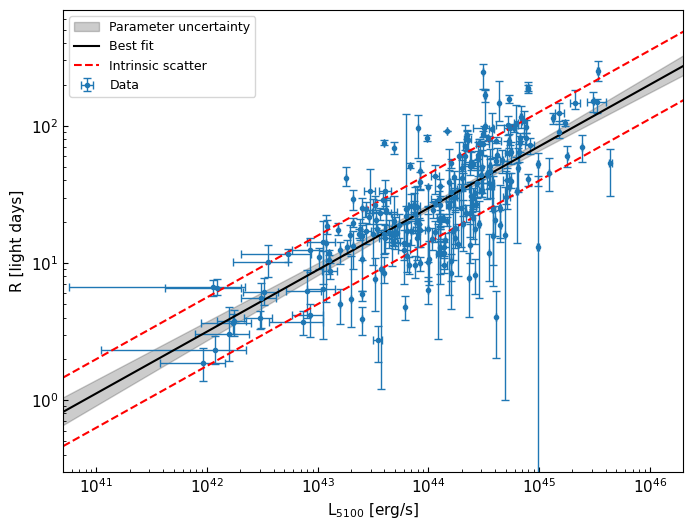

In [63]:
data = pd.read_csv(r'A:\\UniDokumente\\Projektpraktikum\\check_db_sim\\results_3.csv', header = 0)

fit_data = data.mask(data['flag'] == 3).dropna()


names = fit_data['name'].to_list()
sources = fit_data['source'].to_list()
rep_lags = fit_data['reported lag'].to_list()
rep_lum = fit_data['luminosity'].to_list()

lags = []
lags_error_plus = []
lags_error_minus = []
lum = []
lum_error = []

for i in range(len(names)):
    if sources[i] == 'Bentz2013':
        cursor = objects.find_one({'names': names[i]})
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        main_reference = corr_entry['main reference']
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])
        lum_entries = cursor.get('properties').get('L5100').get('Bentz2013')
        for j in range(len(lum_entries)):
            curr_entry = lum_entries[j]
            if np.round(curr_entry['value'], -42) == np.round(rep_lum[i], -42):
                corr_indx = j
        corr_entry = lum_entries[corr_indx]
        lum.append(corr_entry['value'] / 1e44)
        lum_error.append(corr_entry['error'] / 1e44)
    else:
        cursor = objects.find_one({'names': names[i]})
        L, L_error = get_luminosity(cursor, 'L5100', mode = 'simple', source = sources[i])
        lum.append(L / 1e44)
        lum_error.append(L_error / 1e44)
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])


x_plot = np.linspace(5e40, 1e47, 1000) / 1e44

y_med, y_low, y_high, y_s_lo, y_s_hi = rl_model_with_errors(
    x_plot, 0.45, 0.03, 0.03, 1.40, 0.02, 0.02, 0.25)



plt.figure(figsize = (8,6))
plt.xscale('log')
plt.yscale('log')
plt.errorbar(lum, lags ,xerr =lum_error ,yerr = [lags_error_minus, lags_error_plus] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Data')
plt.fill_between(x_plot, y_low, y_high, color='black', alpha=0.2, label = 'Parameter uncertainty')
plt.plot(x_plot, y_med, color='black', label = 'Best fit')
plt.plot(x_plot, y_s_lo, color = 'red', ls = '--', alpha = 1, label = 'Intrinsic scatter')
plt.plot(x_plot, y_s_hi, color = 'red', ls = '--', alpha = 1)
plt.xlabel(r'L$_{5100}$ [erg/s]')
plt.ylabel('R [light days]')
#plt.title(r'R-L $H_\beta$ for all categories')
plt.tick_params(which='major', direction='in')
plt.tick_params(which='minor', direction='in')
plt.legend(loc = 'upper left')
plt.ylim(3e-1,7e2)
plt.xlim(5e-4,2e2)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: rf'$10^{{{int(np.log10(val*1e44))}}}$')
)
plt.savefig(r'R_L_paper_figures\fit_loose_cat_012.pdf', bbox_inches = 'tight', dpi = 600)

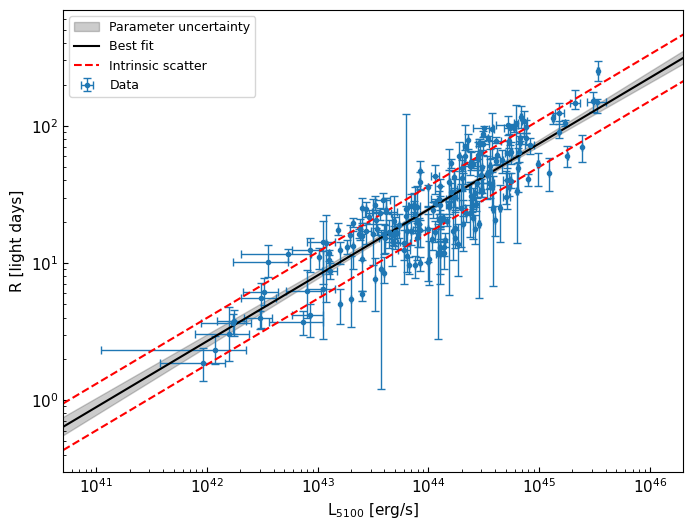

In [64]:
data = pd.read_csv(r'A:\\UniDokumente\\Projektpraktikum\\check_db_sim\\results_3.csv', header = 0)

fit_data = data.mask(data['flag'] == 3).dropna()
fit_data = fit_data.mask(data['flag'] == 2).dropna()

names = fit_data['name'].to_list()
sources = fit_data['source'].to_list()
rep_lags = fit_data['reported lag'].to_list()
rep_lum = fit_data['luminosity'].to_list()

lags = []
lags_error_plus = []
lags_error_minus = []
lum = []
lum_error = []

for i in range(len(names)):
    if sources[i] == 'Bentz2013':
        cursor = objects.find_one({'names': names[i]})
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        main_reference = corr_entry['main reference']
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])
        lum_entries = cursor.get('properties').get('L5100').get('Bentz2013')
        for j in range(len(lum_entries)):
            curr_entry = lum_entries[j]
            if np.round(curr_entry['value'], -42) == np.round(rep_lum[i], -42):
                corr_indx = j
        corr_entry = lum_entries[corr_indx]
        lum.append(corr_entry['value'] / 1e44)
        lum_error.append(corr_entry['error'] / 1e44)
    else:
        cursor = objects.find_one({'names': names[i]})
        L, L_error = get_luminosity(cursor, 'L5100', mode = 'simple', source = sources[i])
        lum.append(L / 1e44)
        lum_error.append(L_error / 1e44)
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])


x_plot = np.linspace(5e40, 1e47, 1000) / 1e44

y_med, y_low, y_high, y_s_lo, y_s_hi = rl_model_with_errors(
    x_plot, 0.48, 0.02, 0.02, 1.39, 0.01, 0.01, 0.17)



plt.figure(figsize = (8,6))
plt.xscale('log')
plt.yscale('log')
plt.errorbar(lum, lags ,xerr =lum_error ,yerr = [lags_error_minus, lags_error_plus] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Data')
plt.fill_between(x_plot, y_low, y_high, color='black', alpha=0.2, label = 'Parameter uncertainty')
plt.plot(x_plot, y_med, color='black', label = 'Best fit')
plt.plot(x_plot, y_s_lo, color = 'red', ls = '--', alpha = 1, label = 'Intrinsic scatter')
plt.plot(x_plot, y_s_hi, color = 'red', ls = '--', alpha = 1)
plt.xlabel(r'L$_{5100}$ [erg/s]')
plt.ylabel('R [light days]')
#plt.title(r'R-L $H_\beta$ for all categories')
plt.tick_params(which='major', direction='in')
plt.tick_params(which='minor', direction='in')
plt.legend(loc = 'upper left')
plt.ylim(3e-1,7e2)
plt.xlim(5e-4,2e2)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: rf'$10^{{{int(np.log10(val*1e44))}}}$')
)
plt.savefig(r'R_L_paper_figures\fit_loose_cat_01.pdf', bbox_inches = 'tight', dpi = 600)

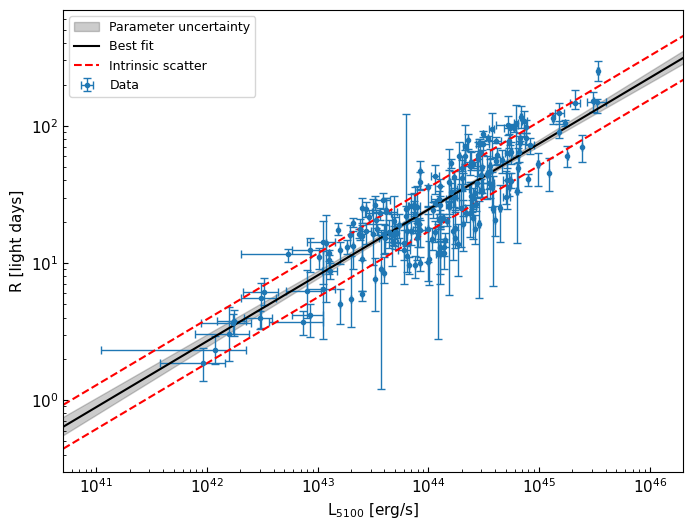

In [65]:
data = pd.read_csv(r'A:\\UniDokumente\\Projektpraktikum\\check_db_sim\\results_3.csv', header = 0)

fit_data = data.mask(data['flag'] != 0).dropna()


names = fit_data['name'].to_list()
sources = fit_data['source'].to_list()
rep_lags = fit_data['reported lag'].to_list()
rep_lum = fit_data['luminosity'].to_list()

lags = []
lags_error_plus = []
lags_error_minus = []
lum = []
lum_error = []

for i in range(len(names)):
    if sources[i] == 'Bentz2013':
        cursor = objects.find_one({'names': names[i]})
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        main_reference = corr_entry['main reference']
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])
        lum_entries = cursor.get('properties').get('L5100').get('Bentz2013')
        for j in range(len(lum_entries)):
            curr_entry = lum_entries[j]
            if np.round(curr_entry['value'], -42) == np.round(rep_lum[i], -42):
                corr_indx = j
        corr_entry = lum_entries[corr_indx]
        lum.append(corr_entry['value'] / 1e44)
        lum_error.append(corr_entry['error'] / 1e44)
    else:
        cursor = objects.find_one({'names': names[i]})
        L, L_error = get_luminosity(cursor, 'L5100', mode = 'simple', source = sources[i])
        lum.append(L / 1e44)
        lum_error.append(L_error / 1e44)
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])


x_plot = np.linspace(5e40, 1e47, 1000) / 1e44

y_med, y_low, y_high, y_s_lo, y_s_hi = rl_model_with_errors(
    x_plot, 0.48, 0.02, 0.02, 1.39, 0.01, 0.01, 0.16)


plt.figure(figsize = (8,6))
plt.xscale('log')
plt.yscale('log')
plt.errorbar(lum, lags ,xerr =lum_error ,yerr = [lags_error_minus, lags_error_plus] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Data')
plt.fill_between(x_plot, y_low, y_high, color='black', alpha=0.2, label = 'Parameter uncertainty')
plt.plot(x_plot, y_med, color='black', label = 'Best fit')
plt.plot(x_plot, y_s_lo, color = 'red', ls = '--', alpha = 1, label = 'Intrinsic scatter')
plt.plot(x_plot, y_s_hi, color = 'red', ls = '--', alpha = 1)
plt.xlabel(r'L$_{5100}$ [erg/s]')
plt.ylabel('R [light days]')
#plt.title(r'R-L $H_\beta$ for all categories')
plt.tick_params(which='major', direction='in')
plt.tick_params(which='minor', direction='in')
plt.legend(loc = 'upper left')
plt.ylim(3e-1,7e2)
plt.xlim(5e-4,2e2)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: rf'$10^{{{int(np.log10(val*1e44))}}}$')
)
plt.savefig(r'R_L_paper_figures\fit_loose_cat_0.pdf', bbox_inches = 'tight', dpi = 600)

Slope of $\frac{1}{3}$

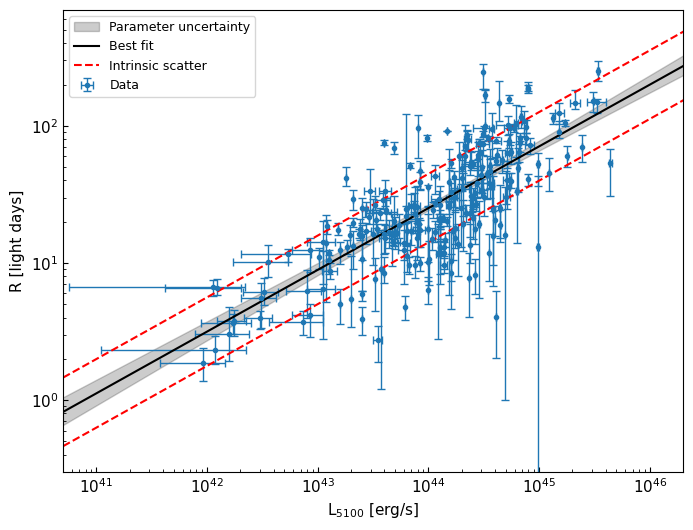

In [66]:
data = pd.read_csv(r'A:\\UniDokumente\\Projektpraktikum\\check_db_sim_2\\results.csv', header = 0)

fit_data = data.mask(data['flag'] == 3).dropna()


names = fit_data['name'].to_list()
sources = fit_data['source'].to_list()
rep_lags = fit_data['reported lag'].to_list()
rep_lum = fit_data['luminosity'].to_list()

lags = []
lags_error_plus = []
lags_error_minus = []
lum = []
lum_error = []

for i in range(len(names)):
    if sources[i] == 'Bentz2013':
        cursor = objects.find_one({'names': names[i]})
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        main_reference = corr_entry['main reference']
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])
        lum_entries = cursor.get('properties').get('L5100').get('Bentz2013')
        for j in range(len(lum_entries)):
            curr_entry = lum_entries[j]
            if np.round(curr_entry['value'], -42) == np.round(rep_lum[i], -42):
                corr_indx = j
        corr_entry = lum_entries[corr_indx]
        lum.append(corr_entry['value'] / 1e44)
        lum_error.append(corr_entry['error'] / 1e44)
    else:
        cursor = objects.find_one({'names': names[i]})
        L, L_error = get_luminosity(cursor, 'L5100', mode = 'simple', source = sources[i])
        lum.append(L / 1e44)
        lum_error.append(L_error / 1e44)
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])


x_plot = np.linspace(5e40, 1e47, 1000) / 1e44

y_med, y_low, y_high, y_s_lo, y_s_hi = rl_model_with_errors(
    x_plot, 0.45, 0.03, 0.03, 1.40, 0.02, 0.02, 0.25)



plt.figure(figsize = (8,6))
plt.xscale('log')
plt.yscale('log')
plt.errorbar(lum, lags ,xerr =lum_error ,yerr = [lags_error_minus, lags_error_plus] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Data')
plt.fill_between(x_plot, y_low, y_high, color='black', alpha=0.2, label = 'Parameter uncertainty')
plt.plot(x_plot, y_med, color='black', label = 'Best fit')
plt.plot(x_plot, y_s_lo, color = 'red', ls = '--', alpha = 1, label = 'Intrinsic scatter')
plt.plot(x_plot, y_s_hi, color = 'red', ls = '--', alpha = 1)
plt.xlabel(r'L$_{5100}$ [erg/s]')
plt.ylabel('R [light days]')
#plt.title(r'R-L $H_\beta$ for all categories')
plt.tick_params(which='major', direction='in')
plt.tick_params(which='minor', direction='in')
plt.legend(loc = 'upper left')
plt.ylim(3e-1,7e2)
plt.xlim(5e-4,2e2)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: rf'$10^{{{int(np.log10(val*1e44))}}}$')
)
plt.savefig(r'R_L_paper_figures\fit_03_cat_012.pdf', bbox_inches = 'tight', dpi = 600)

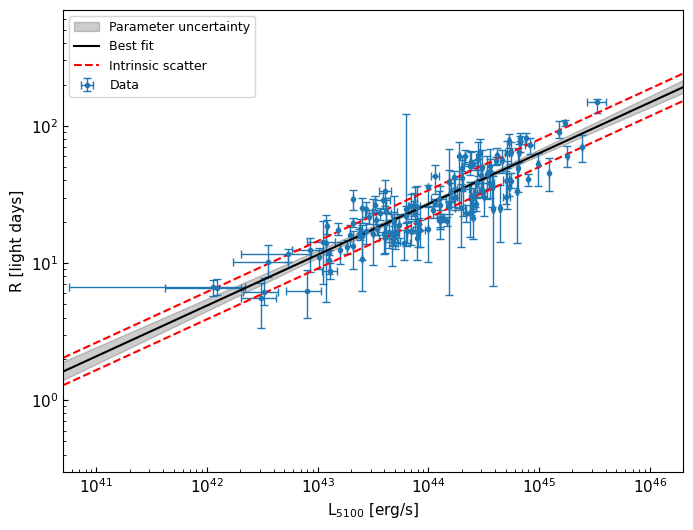

In [67]:
data = pd.read_csv(r'A:\\UniDokumente\\Projektpraktikum\\check_db_sim_2\\results.csv', header = 0)

fit_data = data.mask(data['flag'] == 3).dropna()
fit_data = fit_data.mask(data['flag'] == 2).dropna()


names = fit_data['name'].to_list()
sources = fit_data['source'].to_list()
rep_lags = fit_data['reported lag'].to_list()
rep_lum = fit_data['luminosity'].to_list()

lags = []
lags_error_plus = []
lags_error_minus = []
lum = []
lum_error = []

for i in range(len(names)):
    if sources[i] == 'Bentz2013':
        cursor = objects.find_one({'names': names[i]})
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        main_reference = corr_entry['main reference']
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])
        lum_entries = cursor.get('properties').get('L5100').get('Bentz2013')
        for j in range(len(lum_entries)):
            curr_entry = lum_entries[j]
            if np.round(curr_entry['value'], -42) == np.round(rep_lum[i], -42):
                corr_indx = j
        corr_entry = lum_entries[corr_indx]
        lum.append(corr_entry['value'] / 1e44)
        lum_error.append(corr_entry['error'] / 1e44)
    else:
        cursor = objects.find_one({'names': names[i]})
        L, L_error = get_luminosity(cursor, 'L5100', mode = 'simple', source = sources[i])
        lum.append(L / 1e44)
        lum_error.append(L_error / 1e44)
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])


x_plot = np.linspace(5e40, 1e47, 1000) / 1e44

y_med, y_low, y_high, y_s_lo, y_s_hi = rl_model_with_errors(
    x_plot, 0.37, 0.02, 0.02, 1.43, 0.01, 0.01, 0.10)



plt.figure(figsize = (8,6))
plt.xscale('log')
plt.yscale('log')
plt.errorbar(lum, lags ,xerr =lum_error ,yerr = [lags_error_minus, lags_error_plus] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Data')
plt.fill_between(x_plot, y_low, y_high, color='black', alpha=0.2, label = 'Parameter uncertainty')
plt.plot(x_plot, y_med, color='black', label = 'Best fit')
plt.plot(x_plot, y_s_lo, color = 'red', ls = '--', alpha = 1, label = 'Intrinsic scatter')
plt.plot(x_plot, y_s_hi, color = 'red', ls = '--', alpha = 1)
plt.xlabel(r'L$_{5100}$ [erg/s]')
plt.ylabel('R [light days]')
#plt.title(r'R-L $H_\beta$ for all categories')
plt.tick_params(which='major', direction='in')
plt.tick_params(which='minor', direction='in')
plt.legend(loc = 'upper left')
plt.ylim(3e-1,7e2)
plt.xlim(5e-4,2e2)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: rf'$10^{{{int(np.log10(val*1e44))}}}$')
)
plt.savefig(r'R_L_paper_figures\fit_03_cat_01.pdf', bbox_inches = 'tight', dpi = 600)

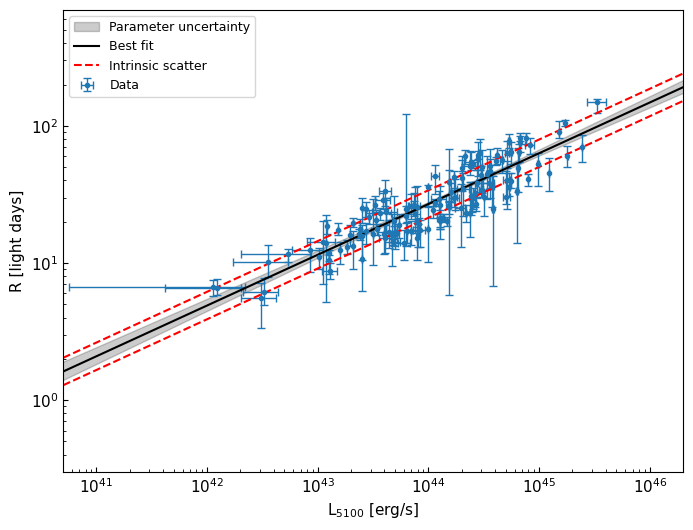

In [68]:
data = pd.read_csv(r'A:\\UniDokumente\\Projektpraktikum\\check_db_sim_2\\results.csv', header = 0)

fit_data = data.mask(data['flag'] != 0).dropna()


names = fit_data['name'].to_list()
sources = fit_data['source'].to_list()
rep_lags = fit_data['reported lag'].to_list()
rep_lum = fit_data['luminosity'].to_list()

lags = []
lags_error_plus = []
lags_error_minus = []
lum = []
lum_error = []

for i in range(len(names)):
    if sources[i] == 'Bentz2013':
        cursor = objects.find_one({'names': names[i]})
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        main_reference = corr_entry['main reference']
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])
        lum_entries = cursor.get('properties').get('L5100').get('Bentz2013')
        for j in range(len(lum_entries)):
            curr_entry = lum_entries[j]
            if np.round(curr_entry['value'], -42) == np.round(rep_lum[i], -42):
                corr_indx = j
        corr_entry = lum_entries[corr_indx]
        lum.append(corr_entry['value'] / 1e44)
        lum_error.append(corr_entry['error'] / 1e44)
    else:
        cursor = objects.find_one({'names': names[i]})
        L, L_error = get_luminosity(cursor, 'L5100', mode = 'simple', source = sources[i])
        lum.append(L / 1e44)
        lum_error.append(L_error / 1e44)
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])


x_plot = np.linspace(5e40, 1e47, 1000) / 1e44

y_med, y_low, y_high, y_s_lo, y_s_hi = rl_model_with_errors(
    x_plot, 0.37, 0.02, 0.02, 1.43, 0.01, 0.01, 0.10)


plt.figure(figsize = (8,6))
plt.xscale('log')
plt.yscale('log')
plt.errorbar(lum, lags ,xerr =lum_error ,yerr = [lags_error_minus, lags_error_plus] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Data')
plt.fill_between(x_plot, y_low, y_high, color='black', alpha=0.2, label = 'Parameter uncertainty')
plt.plot(x_plot, y_med, color='black', label = 'Best fit')
plt.plot(x_plot, y_s_lo, color = 'red', ls = '--', alpha = 1, label = 'Intrinsic scatter')
plt.plot(x_plot, y_s_hi, color = 'red', ls = '--', alpha = 1)
plt.xlabel(r'L$_{5100}$ [erg/s]')
plt.ylabel('R [light days]')
#plt.title(r'R-L $H_\beta$ for all categories')
plt.tick_params(which='major', direction='in')
plt.tick_params(which='minor', direction='in')
plt.legend(loc = 'upper left')
plt.ylim(3e-1,7e2)
plt.xlim(5e-4,2e2)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: rf'$10^{{{int(np.log10(val*1e44))}}}$')
)
plt.savefig(r'R_L_paper_figures\fit_03_cat_0.pdf', bbox_inches = 'tight', dpi = 600)

reference slope of 0.7

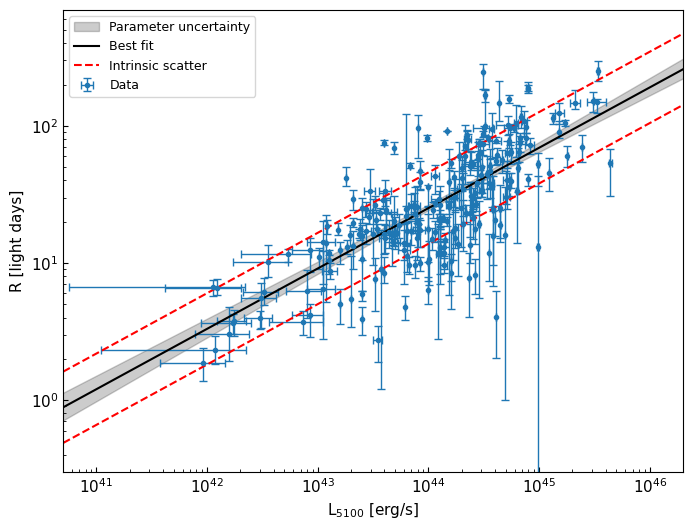

In [69]:
data = pd.read_csv(r'A:\\UniDokumente\\Projektpraktikum\\check_db_sim_3\\results.csv', header = 0)

fit_data = data.mask(data['flag'] == 3).dropna()



names = fit_data['name'].to_list()
sources = fit_data['source'].to_list()
rep_lags = fit_data['reported lag'].to_list()
rep_lum = fit_data['luminosity'].to_list()

lags = []
lags_error_plus = []
lags_error_minus = []
lum = []
lum_error = []

for i in range(len(names)):
    if sources[i] == 'Bentz2013':
        cursor = objects.find_one({'names': names[i]})
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        main_reference = corr_entry['main reference']
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])
        lum_entries = cursor.get('properties').get('L5100').get('Bentz2013')
        for j in range(len(lum_entries)):
            curr_entry = lum_entries[j]
            if np.round(curr_entry['value'], -42) == np.round(rep_lum[i], -42):
                corr_indx = j
        corr_entry = lum_entries[corr_indx]
        lum.append(corr_entry['value'] / 1e44)
        lum_error.append(corr_entry['error'] / 1e44)
    else:
        cursor = objects.find_one({'names': names[i]})
        L, L_error = get_luminosity(cursor, 'L5100', mode = 'simple', source = sources[i])
        lum.append(L / 1e44)
        lum_error.append(L_error / 1e44)
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])


x_plot = np.linspace(5e40, 1e47, 1000) / 1e44

y_med, y_low, y_high, y_s_lo, y_s_hi = rl_model_with_errors(
    x_plot, 0.44, 0.03, 0.03, 1.40, 0.02, 0.02, 0.26)



plt.figure(figsize = (8,6))
plt.xscale('log')
plt.yscale('log')
plt.errorbar(lum, lags ,xerr =lum_error ,yerr = [lags_error_minus, lags_error_plus] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Data')
plt.fill_between(x_plot, y_low, y_high, color='black', alpha=0.2, label = 'Parameter uncertainty')
plt.plot(x_plot, y_med, color='black', label = 'Best fit')
plt.plot(x_plot, y_s_lo, color = 'red', ls = '--', alpha = 1, label = 'Intrinsic scatter')
plt.plot(x_plot, y_s_hi, color = 'red', ls = '--', alpha = 1)
plt.xlabel(r'L$_{5100}$ [erg/s]')
plt.ylabel('R [light days]')
#plt.title(r'R-L $H_\beta$ for all categories')
plt.tick_params(which='major', direction='in')
plt.tick_params(which='minor', direction='in')
plt.legend(loc = 'upper left')
plt.ylim(3e-1,7e2)
plt.xlim(5e-4,2e2)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: rf'$10^{{{int(np.log10(val*1e44))}}}$')
)
plt.savefig(r'R_L_paper_figures\fit_07_cat_012.pdf', bbox_inches = 'tight', dpi = 600)

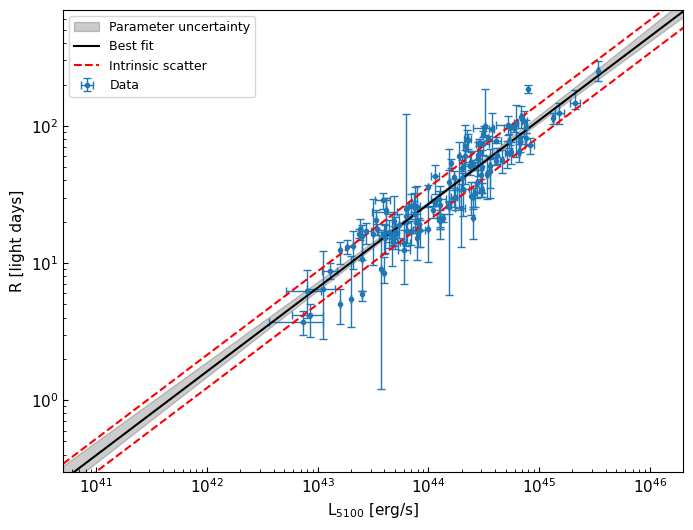

In [70]:
data = pd.read_csv(r'A:\\UniDokumente\\Projektpraktikum\\check_db_sim_3\\results.csv', header = 0)

fit_data = data.mask(data['flag'] == 3).dropna()
fit_data = fit_data.mask(data['flag'] == 2).dropna()


names = fit_data['name'].to_list()
sources = fit_data['source'].to_list()
rep_lags = fit_data['reported lag'].to_list()
rep_lum = fit_data['luminosity'].to_list()

lags = []
lags_error_plus = []
lags_error_minus = []
lum = []
lum_error = []

for i in range(len(names)):
    if sources[i] == 'Bentz2013':
        cursor = objects.find_one({'names': names[i]})
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        main_reference = corr_entry['main reference']
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])
        lum_entries = cursor.get('properties').get('L5100').get('Bentz2013')
        for j in range(len(lum_entries)):
            curr_entry = lum_entries[j]
            if np.round(curr_entry['value'], -42) == np.round(rep_lum[i], -42):
                corr_indx = j
        corr_entry = lum_entries[corr_indx]
        lum.append(corr_entry['value'] / 1e44)
        lum_error.append(corr_entry['error'] / 1e44)
    else:
        cursor = objects.find_one({'names': names[i]})
        L, L_error = get_luminosity(cursor, 'L5100', mode = 'simple', source = sources[i])
        lum.append(L / 1e44)
        lum_error.append(L_error / 1e44)
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])


x_plot = np.linspace(5e40, 1e47, 1000) / 1e44

y_med, y_low, y_high, y_s_lo, y_s_hi = rl_model_with_errors(
    x_plot, 0.61, 0.02, 0.03, 1.43, 0.01, 0.01, 0.12)



plt.figure(figsize = (8,6))
plt.xscale('log')
plt.yscale('log')
plt.errorbar(lum, lags ,xerr =lum_error ,yerr = [lags_error_minus, lags_error_plus] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Data')
plt.fill_between(x_plot, y_low, y_high, color='black', alpha=0.2, label = 'Parameter uncertainty')
plt.plot(x_plot, y_med, color='black', label = 'Best fit')
plt.plot(x_plot, y_s_lo, color = 'red', ls = '--', alpha = 1, label = 'Intrinsic scatter')
plt.plot(x_plot, y_s_hi, color = 'red', ls = '--', alpha = 1)
plt.xlabel(r'L$_{5100}$ [erg/s]')
plt.ylabel('R [light days]')
#plt.title(r'R-L $H_\beta$ for all categories')
plt.tick_params(which='major', direction='in')
plt.tick_params(which='minor', direction='in')
plt.legend(loc = 'upper left')
plt.ylim(3e-1,7e2)
plt.xlim(5e-4,2e2)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: rf'$10^{{{int(np.log10(val*1e44))}}}$')
)
plt.savefig(r'R_L_paper_figures\fit_07_cat_01.pdf', bbox_inches = 'tight', dpi = 600)

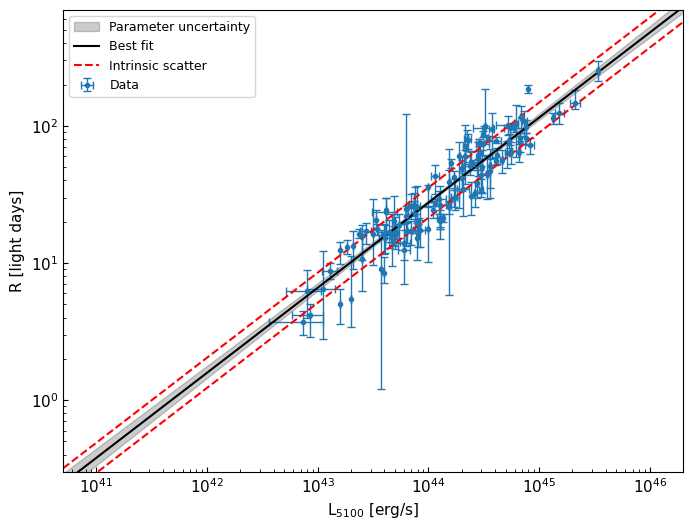

In [71]:
data = pd.read_csv(r'A:\\UniDokumente\\Projektpraktikum\\check_db_sim_3\\results.csv', header = 0)

fit_data = data.mask(data['flag'] != 0).dropna()



names = fit_data['name'].to_list()
sources = fit_data['source'].to_list()
rep_lags = fit_data['reported lag'].to_list()
rep_lum = fit_data['luminosity'].to_list()

lags = []
lags_error_plus = []
lags_error_minus = []
lum = []
lum_error = []

for i in range(len(names)):
    if sources[i] == 'Bentz2013':
        cursor = objects.find_one({'names': names[i]})
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        main_reference = corr_entry['main reference']
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])
        lum_entries = cursor.get('properties').get('L5100').get('Bentz2013')
        for j in range(len(lum_entries)):
            curr_entry = lum_entries[j]
            if np.round(curr_entry['value'], -42) == np.round(rep_lum[i], -42):
                corr_indx = j
        corr_entry = lum_entries[corr_indx]
        lum.append(corr_entry['value'] / 1e44)
        lum_error.append(corr_entry['error'] / 1e44)
    else:
        cursor = objects.find_one({'names': names[i]})
        L, L_error = get_luminosity(cursor, 'L5100', mode = 'simple', source = sources[i])
        lum.append(L / 1e44)
        lum_error.append(L_error / 1e44)
        lag_entries = cursor.get('properties').get('lags').get('H_beta')
        for j in range(len(lag_entries)):
            curr_entry = lag_entries[j]
            if np.round(curr_entry['value'], 3) == np.round(rep_lags[i], 3):
                corr_indx = j
        corr_entry = lag_entries[corr_indx]
        lags.append(corr_entry['value'])
        lags_error_plus.append(corr_entry['error +'])
        lags_error_minus.append(corr_entry['error -'])


x_plot = np.linspace(5e40, 1e47, 1000) / 1e44

y_med, y_low, y_high, y_s_lo, y_s_hi = rl_model_with_errors(
    x_plot, 0.62, 0.02, 0.02, 1.44, 0.01, 0.01, 0.11)


plt.figure(figsize = (8,6))
plt.xscale('log')
plt.yscale('log')
plt.errorbar(lum, lags ,xerr =lum_error ,yerr = [lags_error_minus, lags_error_plus] ,ls = 'None', fmt = 'o', elinewidth=1, capsize = 3, ms = 3, label = 'Data')
plt.fill_between(x_plot, y_low, y_high, color='black', alpha=0.2, label = 'Parameter uncertainty')
plt.plot(x_plot, y_med, color='black', label = 'Best fit')
plt.plot(x_plot, y_s_lo, color = 'red', ls = '--', alpha = 1, label = 'Intrinsic scatter')
plt.plot(x_plot, y_s_hi, color = 'red', ls = '--', alpha = 1)
plt.xlabel(r'L$_{5100}$ [erg/s]')
plt.ylabel('R [light days]')
#plt.title(r'R-L $H_\beta$ for all categories')
plt.tick_params(which='major', direction='in')
plt.tick_params(which='minor', direction='in')
plt.legend(loc = 'upper left')
plt.ylim(3e-1,7e2)
plt.xlim(5e-4,2e2)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: rf'$10^{{{int(np.log10(val*1e44))}}}$')
)
plt.savefig(r'R_L_paper_figures\fit_07_cat_0.pdf', bbox_inches = 'tight', dpi = 600)

### Comparison of fitting parameters with the literature

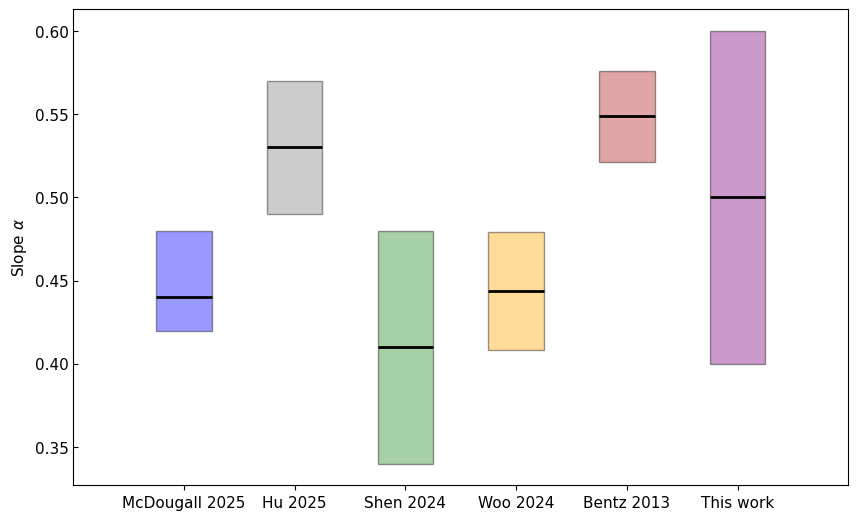

In [48]:
labels = ['McDougall 2025','Hu 2025','Shen 2024','Woo 2024','Bentz 2013','This work']

alpha = np.array([0.44, 0.53, 0.41, 0.444, 0.549, 0.50])

err_minus = np.array([0.02, 0.04, 0.07, 0.036, 0.028, 0.1])
err_plus  = np.array([0.04, 0.04, 0.07, 0.035, 0.027, 0.1])

colors = ['blue','gray','forestgreen','orange','firebrick','purple']

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize = (10, 10 / 1.618))

box_width = 0.5

for i in range(len(labels)):
    y_bottom = alpha[i] - err_minus[i]
    height = err_minus[i] + err_plus[i]
    rect = Rectangle((x[i] - box_width/2, y_bottom),box_width,height,facecolor=colors[i],alpha=0.4,edgecolor='black')
    ax.add_patch(rect)
    ax.hlines(alpha[i],x[i] - box_width/2,x[i] + box_width/2,color='black',linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel(r'Slope $\alpha$')
ax.set_xlim(-1, len(labels))
ax.tick_params(axis = 'y', direction='in')
#ax.tick_params(axis = 'x', direction='in')

plt.savefig('R_L_paper_figures\lit_comparison_slope.pdf', bbox_inches = 'tight', dpi = 600)

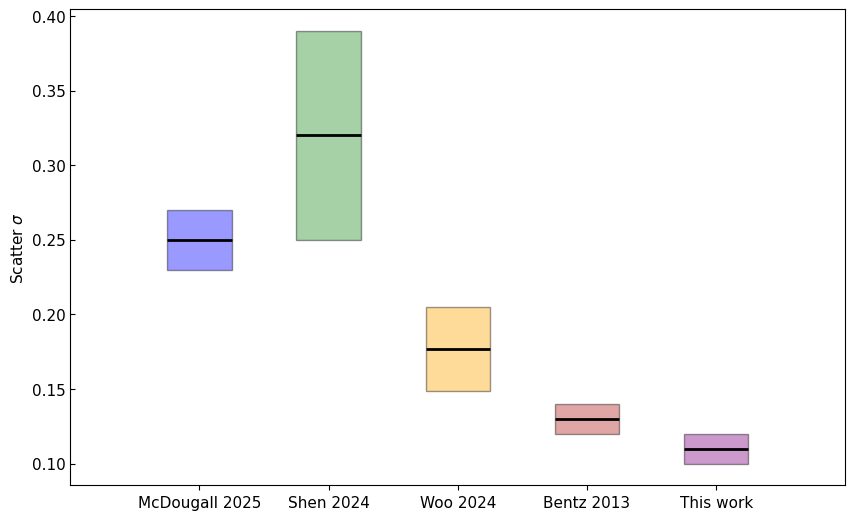

In [49]:
labels = ['McDougall 2025','Shen 2024','Woo 2024','Bentz 2013','This work']

alpha = np.array([0.25, 0.32, 0.177, 0.13, 0.11])

err_minus = np.array([0.02, 0.07, 0.028, 0.01, 0.01])
err_plus  = np.array([0.02, 0.07, 0.028, 0.01, 0.01])

colors = ['blue','forestgreen','orange','firebrick','purple']

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize = (10, 10 / 1.618))

box_width = 0.5

for i in range(len(labels)):
    y_bottom = alpha[i] - err_minus[i]
    height = err_minus[i] + err_plus[i]
    rect = Rectangle((x[i] - box_width/2, y_bottom),box_width,height,facecolor=colors[i],alpha=0.4,edgecolor='black')
    ax.add_patch(rect)
    ax.hlines(alpha[i],x[i] - box_width/2,x[i] + box_width/2,color='black',linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel(r'Scatter $\sigma$')
ax.set_xlim(-1, len(labels))
ax.tick_params(axis = 'y', direction='in')
plt.savefig('R_L_paper_figures\lit_comparison_scatter.pdf', bbox_inches = 'tight', dpi = 600)